This is the first part of the trainer-teacher idea that is enforced in the literature for encouraging a TSE to learn. It was previously done in the NON CAUSAL setup, but this is the attempt to make it for causal. This model will be using the baseline of the ecapa, which I will attach a classification head to. The idea is that this model will take a piece of audio and classify for 4 classes conditioned on the enrollment: Target, Interferer, Both, Neither. From this we will use the teacher for 2 heads in the training process of our model. Head A: Does the classified estimation correctly identify the class, Head B: does the eventual class classified sound either as target only or neither (ie is our extractor changing the interferer only and both trials to sound like class neither and target only respectively). 

  What ECAPA actually is: a network trained on VoxCeleb to answer "are these two recordings the same person". It was never trained to transcribe. That is the entire difference from WavLM, which was trained to predict masked audio and therefore encodes what is said.


# 1. paths, pins, imports

In [2]:
import csv, glob, hashlib, sys
from pathlib import Path

import numpy as np
import soundfile as sf
import torch
import torch.nn as nn

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.data import state_labels as sl
from src.data import vad

ECAPA_DIR = REPO.parent / "ecapa_pretrained"
RENDERED  = REPO / "data" / "rendered"
INDEX     = REPO / "data" / "index"
CACHE     = REPO.parent / "state_detector_cache"

SAMPLE_RATE   = 16000
EMBEDDING_DIM = 192
WINDOW_SECONDS     = 1.0
WINDOW_HOP_SECONDS = 0.25
WINDOW_SAMPLES     = int(WINDOW_SECONDS * SAMPLE_RATE)
WINDOW_HOP_SAMPLES = int(WINDOW_HOP_SECONDS * SAMPLE_RATE)
CHUNK_SECONDS = 4.008
CHUNK_SAMPLES = int(round(CHUNK_SECONDS * SAMPLE_RATE))
LABEL_HOP_SECONDS = 0.008

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.set_num_threads(4)
def windows_in(n_samples):
    """Start offsets of every whole window that fits inside n_samples."""
    return list(range(0, n_samples - WINDOW_SAMPLES + 1, WINDOW_HOP_SAMPLES))
    
WINDOWS_PER_CHUNK = len(windows_in(CHUNK_SAMPLES))

print(f"seed {RANDOM_SEED}")
print(f"chunk {CHUNK_SECONDS} s -> {WINDOWS_PER_CHUNK} windows of "
    f"{WINDOW_SECONDS} s every {WINDOW_HOP_SECONDS} s")
    

ECAPA_HASHES = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                for p in sorted(ECAPA_DIR.glob("*.ckpt"))}
for name, digest in ECAPA_HASHES.items():
    print(f"  {name:26s} {digest[:16]}...")



seed 42
chunk 4.008 s -> 13 windows of 1.0 s every 0.25 s
  classifier.ckpt            fd9e3634fe68bd0a...
  embedding_model.ckpt       0575cb64845e6b9a...
  label_encoder.ckpt         e13c3a167bb41126...
  mean_var_norm_emb.ckpt     cd70225b05b37be6...


# 2. The frozen backbone

ECAPA-TDNN (Desplanques et al., Interspeech 2020), SpeechBrain's VoxCeleb
checkpoint. **Nothing here trains.** It converts audio into a 192-number
description of the voice, and those numbers are all the head ever sees.

Two design points worth stating:

- **`source` and `savedir` both point at our snapshot**, so nothing is fetched
  at runtime. Kaggle runs with networking off, and an unpinned download would
  make every number irreproducible.
- **`embed_windows` batches**, but only modestly: 78 ms per window batched
  against 102 ms alone. The cost is the 20.8 M-parameter forward, not call
  overhead.

`embed_whole` is used for the enrolment. It is the exact call the 0.957 AUC was
measured with, so the cache stays faithful to that measurement.

In [3]:
from speechbrain.inference.speaker import EncoderClassifier

# source and savedir both point at our snapshot, so nothing is fetched at
# runtime. speechbrain 1.1.1 specifically: 1.0.3 and earlier call
# torchaudio.list_audio_backends(), which torchaudio 2.11 removed.
speaker_encoder = EncoderClassifier.from_hparams(
    source=str(ECAPA_DIR), savedir=str(ECAPA_DIR), run_opts={"device": "cpu"})
speaker_encoder.eval()
for parameter in speaker_encoder.mods.parameters():
    parameter.requires_grad = False # here we are freezing the model
    
parameter_count = sum(p.numel() for p in
                    speaker_encoder.mods.embedding_model.parameters())
print(f"ECAPA-TDNN {parameter_count / 1e6:.2f} M parameters, frozen")


@torch.inference_mode()
def embed_windows(audio, window_starts):
    """Audio plus window offsets -> one ECAPA embedding per window.
    
    (n_windows, 192) float32. Batched into a single call: measured 78 ms per
    window batched against 102 ms unbatched, so batching is a modest win, not
    a large one -- the cost is the 20.8 M-parameter forward, not the overhead.
    """
    batch = np.stack([audio[start:start + WINDOW_SAMPLES]
                    for start in window_starts])
    embeddings = speaker_encoder.encode_batch(torch.from_numpy(batch))
    return embeddings.squeeze(1).numpy()


@torch.inference_mode()
def embed_whole(audio):
    """One embedding for a whole recording. (192,) float32.
    
    Used for the enrolment, which is 5 s and needs no windowing -- and this is
    exactly the call the 0.957 AUC was measured with, so the cache stays
    faithful to the measurement.
    """
    embedding = speaker_encoder.encode_batch(
        torch.from_numpy(audio).unsqueeze(0))
    return embedding.squeeze().numpy()

probe = embed_windows(np.zeros(CHUNK_SAMPLES, dtype=np.float32),
                    windows_in(CHUNK_SAMPLES))
print(f"chunk -> {probe.shape}   enrolment -> "
    f"{embed_whole(np.zeros(5 * SAMPLE_RATE, dtype=np.float32)).shape}")

ECAPA-TDNN 20.77 M parameters, frozen
chunk -> (13, 192)   enrolment -> (192,)


# 3. Labels: one state per window

**Problem.** ECAPA needs about a second of audio to describe a voice, but a
speaker state can change faster than that. So a 1 s window may hold several
states and still needs one label.

**Solution.** Take the majority state over the window's 8 ms frames, and record
`purity` -- how much of the 125 available frames is the label actually present. 1.0 means the whole clip contained the label for that class per frame. Impure windows can then be
filtered or down-weighted rather than silently trusted.

**Reason.** The alternative, "which speakers are active anywhere in this
window", would label nearly every window `both` and destroy the distinction the
teacher exists to make.

**What gets cached is the two boolean masks, not the finished labels.** The
audibility threshold `AUDIBLE_DB` decides how quiet a residual interferer has to
be before a window stops counting as `both`, and that constant is the operating
point of the entire training term. Caching masks keeps it a free parameter --
change it and labels re-derive in seconds instead of an hour of re-caching.

The assertions at the bottom are the only cheap place to catch a misalignment.
Inside a training loop, a one-window offset just looks like a teacher that
learns badly. **Read the printed state line**: it should show blocky runs of the
same letter, because speaker states last hundreds of milliseconds. Flickering
single windows would mean the spans are wrong.

In [4]:
FRAMES_PER_WINDOW = int(round(WINDOW_SECONDS / LABEL_HOP_SECONDS))


def window_masks(target_spans, interferer_spans, crop_start_samples, window_starts):
    """Who is speaking in every 8 ms frame of every window.

    Returns two (n_windows, FRAMES_PER_WINDOW) boolean arrays. Deliberately
    gain-free: these describe the ORIGINAL trial, so the same masks serve any
    variant and any audibility threshold. Essentially just says who is speaking in each frame inside each window.
    """
    target_active, interferer_active = [], []
    for window_start in window_starts:
        offset_seconds = (crop_start_samples + window_start) / SAMPLE_RATE
        target_active.append(sl.spans_to_mask(
            target_spans, FRAMES_PER_WINDOW, LABEL_HOP_SECONDS, offset_seconds))
        interferer_active.append(sl.spans_to_mask(
            interferer_spans, FRAMES_PER_WINDOW, LABEL_HOP_SECONDS,
            offset_seconds))
    return np.stack(target_active), np.stack(interferer_active)


def bits_from_window_masks(target_active, interferer_active,
                           target_gain, interferer_audible):
    """Masks plus this variant's gains -> TWO independent binary labels.

    Returns (target_audible, interferer_audible, target_purity,
    interferer_purity), each (n_windows,).

    WHY TWO BITS RATHER THAN FOUR STATES
    ------------------------------------
    The four states were always a pair of bits -- `sl.states_from_masks` builds
    them as target = bit 0, interferer = bit 1 -- so `both` is the CONJUNCTION
    of two conditions, not a fifth category. MEASURED 2026-09-10 on the same
    predictions: `both` read 0.369 as a 4-way class while the two questions it
    is made of read 0.857 and 0.767. The 4-way softmax was hiding what the head
    knew, by forcing it to commit to one of four categories instead of
    answering two independent questions.

    It also lets each question carry its OWN operating point, which they need:
    the loss should be quick to accept "the target is present" and cautious
    about declaring "the interferer is gone".

    Each bit is the majority over the window's frames, taken INDEPENDENTLY, and
    each gets its own purity. That removes the tie problem entirely -- a bit is
    a two-way vote over an odd-or-even count, and its purity is bounded below by
    0.5 rather than 0.25.
    """
    target_frames_on = (target_active & (target_gain > 0)).mean(axis=1)
    interferer_frames_on = (interferer_active & interferer_audible).mean(axis=1)
    return (
        target_frames_on >= 0.5,
        interferer_frames_on >= 0.5,
        np.maximum(target_frames_on, 1.0 - target_frames_on).astype(np.float32),
        np.maximum(interferer_frames_on,
                   1.0 - interferer_frames_on).astype(np.float32),
    )


def four_way_states(target_audible, interferer_audible):
    """The two bits recombined into the familiar four states, for REPORTING
    only. Never used by the loss."""
    return sl.states_from_masks(target_audible, interferer_audible)


split = "sir0_train"
labels = {r["trial_id"]: r
          for r in csv.DictReader((INDEX / f"state_{split}.csv").open())}
print(f"{len(labels)} trials labelled")

trial_id = next(t for t, r in labels.items()
                if int(r["n_samples"]) > CHUNK_SAMPLES)
row = labels[trial_id]

mixture, sample_rate = sf.read(RENDERED / split / trial_id / "mixture.wav",
                               dtype="float32")
assert sample_rate == SAMPLE_RATE, f"{sample_rate} Hz"
assert len(mixture) == int(row["n_samples"]), "audio disagrees with the index"

crop_start = 0
chunk = mixture[crop_start:crop_start + CHUNK_SAMPLES]
window_starts = windows_in(len(chunk))

embeddings = embed_windows(chunk, window_starts)
target_active, interferer_active = window_masks(
    vad.parse_segments(row["target_spans"]),
    vad.parse_segments(row["interferer_spans"]),
    crop_start, window_starts)
target_audible, interferer_audible, target_purity, interferer_purity = \
    bits_from_window_masks(target_active, interferer_active,
                           target_gain=1.0, interferer_audible=True)
states = four_way_states(target_audible, interferer_audible)

assert len(embeddings) == WINDOWS_PER_CHUNK, embeddings.shape
assert len(target_audible) == WINDOWS_PER_CHUNK, target_audible.shape

print(f"{trial_id}")
print(f"embeddings {embeddings.shape}  masks {target_active.shape}")
print("window states:", " ".join(sl.STATE_NAMES[s][0] for s in states))
print("target    :", " ".join("1" if b else "." for b in target_audible))
print("interferer:", " ".join("1" if b else "." for b in interferer_audible))
print(f"  mean purity  target {target_purity.mean():.2f}  "
      f"interferer {interferer_purity.mean():.2f}")
print("  a bit's purity floor is 0.5, not 0: it is a two-way vote, so the "
      "majority always holds at least half the frames")


9955 trials labelled
sir0_train-42-000000
embeddings (13, 192)  masks (13, 125)
window states: n i i b b b b b b b b b b
target    : . . . 1 1 1 1 1 1 1 1 1 1
interferer: . 1 1 1 1 1 1 1 1 1 1 1 1
  mean purity  target 0.89  interferer 0.94
  a bit's purity floor is 0.5, not 0: it is a two-way vote, so the majority always holds at least half the frames


# 4. The trainable head

The only part that learns. 150 k parameters against ECAPA's frozen 20.8 M.

**Two independent yes/no outputs, not one choice among four:**

- is the **target** audible in this window?
- is a **non-target** audible in this window?

**Why, measured 2026-09-10.** The four states were always a pair of bits --
target active is bit 0, interferer active is bit 1 -- so `both` is the
*conjunction* of two conditions, not a fifth category. A four-way softmax forced
the head to commit to one category, and `both` scored 0.369 while **the same
predictions gave 0.857 and 0.767 on the two questions `both` is made of**. The
output shape was hiding what the head knew.

It also gives each question its own operating point, which they need: the loss
should be quick to accept "the target is present" and cautious about declaring
"the interferer is gone".

**Input, per window:** the window's 192-number voice description, the
enrolment's 192, their elementwise product, and their cosine similarity.

**Why the product.** A linear layer over `[window, enrolment]` can only form
weighted sums, and "how much do these agree" is a *product*. No linear map of a
concatenation computes an inner product between its halves.

**Why the cosine as well.** It is the sum of those 192 product terms once both
are unit length, so it is already in there -- but only as 192 numbers the head
must learn to add. Cosine alone scored AUC 0.951 on the identity question, so
passing it explicitly means the head starts from a working answer.

**And why the head is needed despite that:** on the non-target question, plain
cosine scores **0.405 -- below chance**, because one scalar cannot tell "target"
from "target plus someone else". The head reaches 0.767 from the full
embedding. That question is where it earns its keep.

**No sigmoid on the output.** `BCEWithLogitsLoss` applies it internally, and
applying it twice flattens the gradients without erroring.

In [5]:
class StateHead(nn.Module):
    """Two binary detectors over a SEQUENCE of ECAPA window embeddings.

    Output 0: is the TARGET audible in this window?
    Output 1: is a NON-TARGET audible in this window?

    Personal VAD (Ding et al., ICASSP 2020) and TS-VAD (Medennikov et al.,
    Interspeech 2020) predict frame-level speaker activity from a speaker
    profile. Borrowed with a difference: there it is the system output, here it
    is a FROZEN training signal for an extractor, and the backbone is a stock
    verification model rather than one trained jointly with a separator.

    WHY A RECURRENT HEAD RATHER THAN A PER-WINDOW ONE
    -------------------------------------------------
    MEASURED 2026-09-10, same features, same split, same objective:

        per-window MLP  149 k   mean AUC 0.8836   non-target 0.8199
        BiLSTM          339 k   mean AUC 0.9216   non-target 0.8710
        self-attention  473 k   mean AUC 0.9170   non-target 0.8672

    +5.1 points on the hard question, against +1.7 for doubling the data, +0.8
    for the enrolment bank and +0.5 for 24 rounds of hyperparameter search. Ten
    times the effect of the next best intervention.

    A single window at cosine +0.23 to the enrolment is genuinely ambiguous
    between "the target alone, quieter" and "the target plus someone else" --
    `both` sits at +0.233 between `target` at +0.321 and `interferer` at +0.044,
    because a verification embedding describes whichever voice dominates. Seeing
    the neighbouring windows resolves much of that.

    CAVEAT TO CARRY INTO THE WRITE-UP. Part of the gain is genuine comparison
    across windows; part is temporal SMOOTHING, because speaker states come in
    runs of hundreds of milliseconds and the model learns that prior. The prior
    is legitimate -- real speech behaves that way -- but it means a single
    isolated window of leakage in an otherwise-clean output may be smoothed away
    and go unpenalised. The teacher is therefore better at sustained leakage
    than at brief leakage.

    Bidirectional is deliberate and costs nothing: the teacher never streams, so
    future context is free. It also means this head must never be reused as part
    of the causal extractor.
    """

    def __init__(self, embedding_dim=EMBEDDING_DIM, hidden=128, n_layers=1,
                 dropout=0.1, n_outputs=2):
        super().__init__()
        self.norm_window = nn.LayerNorm(embedding_dim)
        self.norm_enrolment = nn.LayerNorm(embedding_dim)

        # Per-window features first, exactly as the MLP head had them: the
        # window, the enrolment, their elementwise product, and their cosine.
        self.project = nn.Sequential(
            nn.Linear(3 * embedding_dim + 1, hidden), nn.GELU())

        # Then across windows. LSTM rather than a transformer: measured better
        # (0.9216 vs 0.9170), 30 % fewer parameters, and it converged at epoch 1
        # against epoch 7.
        self.across_windows = nn.LSTM(hidden, hidden, num_layers=n_layers,
                                      batch_first=True, bidirectional=True,
                                      dropout=dropout if n_layers > 1 else 0.0)
        self.output = nn.Sequential(nn.Dropout(dropout),
                                    nn.Linear(2 * hidden, n_outputs))

    def per_window_features(self, window_embeddings, enrolment_embedding):
        """(B, W, 192) and (B, 192) -> (B, W, 577).

        The cosine is computed on the RAW embeddings, before LayerNorm, and
        passed as its own input. It is the single most informative feature
        available -- MEASURED AUC 0.951 on the identity question with no
        training at all -- and a linear layer would otherwise have to learn to
        sum 192 product terms to recover it.

        The product is there because agreement is a PRODUCT: no linear map of
        [window, enrolment] can compute an inner product between its halves.
        The two LayerNorms put the three blocks on comparable scales so the
        product is not the quietest input.
        """
        window_unit = torch.nn.functional.normalize(window_embeddings, dim=-1)
        enrolment_unit = torch.nn.functional.normalize(enrolment_embedding,
                                                       dim=-1)
        cosine = (window_unit * enrolment_unit.unsqueeze(1)).sum(-1,
                                                                 keepdim=True)
        window = self.norm_window(window_embeddings)
        enrolment = self.norm_enrolment(enrolment_embedding)
        enrolment = enrolment.unsqueeze(1).expand_as(window)
        return torch.cat([window, enrolment, window * enrolment, cosine],
                         dim=-1)

    def forward(self, window_embeddings, enrolment_embedding):
        """(B, W, 192) and (B, 192) -> logits (B, W, 2).

        Logits, not probabilities. BCEWithLogitsLoss applies the sigmoid itself
        and doing it twice flattens the gradients without erroring.
        """
        hidden = self.project(
            self.per_window_features(window_embeddings, enrolment_embedding))
        hidden, _ = self.across_windows(hidden)
        return self.output(hidden)


detector_head = StateHead()
probe_logits = detector_head(
    torch.randn(4, WINDOWS_PER_CHUNK, EMBEDDING_DIM),
    torch.randn(4, EMBEDDING_DIM))
print(f"logits {tuple(probe_logits.shape)}  "
      f"(batch, windows, [target audible, non-target audible]) | "
      f"{sum(p.numel() for p in detector_head.parameters()) / 1e3:.0f} k "
      f"trainable")
print("to beat: per-window MLP scored mean AUC 0.8836, non-target 0.8199")

logits (4, 13, 2)  (batch, windows, [target audible, non-target audible]) | 339 k trainable
to beat: per-window MLP scored mean AUC 0.8836, non-target 0.8199


# 5. What is frozen and what is training

No default PyTorch printout shows the split, and the split is the design: a
pretrained verification model you did not train, plus a small comparator you
did. Worth being able to state as one sentence.

In [6]:
def describe_the_model(head, encoder, batch_size=16):
    """Print what is frozen, what trains, and the shape of every step."""
    frozen = sum(p.numel() for p in encoder.mods.embedding_model.parameters())
    trainable = sum(p.numel() for p in head.parameters() if p.requires_grad)

    print("=" * 68)
    print("FROZEN  ECAPA-TDNN (SpeechBrain, VoxCeleb)")
    print(f"        {frozen / 1e6:.2f} M parameters, none of them training")
    for name, digest in ECAPA_HASHES.items():
        print(f"        {name:26s} {digest[:16]}...")
    print(f"        run once at cache time, so it costs nothing per epoch here")
    print()
    print("TRAINABLE  StateHead")
    print(head)
    print()
    for name, parameter in head.named_parameters():
        print(f"  {name:22s} {str(tuple(parameter.shape)):14s} "
              f"{parameter.numel():>9,}")
    print(f"  {'total':22s} {'':14s} {trainable:>9,}")
    print()
    print(f"        {trainable / 1e3:.0f} k trainable against "
          f"{frozen / 1e6:.2f} M frozen = "
          f"{100 * trainable / frozen:.2f} % of the backbone")
    print()
    print("DATA FLOW  one batch")
    print(f"  chunk audio        ({batch_size}, {CHUNK_SAMPLES:,})"
          f"        {CHUNK_SECONDS} s at {SAMPLE_RATE} Hz")
    print(f"    -> {WINDOWS_PER_CHUNK} windows of {WINDOW_SECONDS} s every "
          f"{WINDOW_HOP_SECONDS} s")
    print(f"    -> ECAPA           ({batch_size}, {WINDOWS_PER_CHUNK}, "
          f"{EMBEDDING_DIM})       [CACHED]")
    print(f"  enrolment audio    ({batch_size}, {5 * SAMPLE_RATE:,})"
          f"        5 s")
    print(f"    -> ECAPA          ({batch_size}, {EMBEDDING_DIM})"
          f"            [CACHED]")
    print()
    print(f"  concat[window, enrolment, product, cosine]")
    print(f"                     ({batch_size}, {WINDOWS_PER_CHUNK}, "
          f"{3 * EMBEDDING_DIM + 1})")
    print(f"    -> Linear + GELU ({batch_size}, {WINDOWS_PER_CHUNK}, 256)")
    print(f"    -> Linear        ({batch_size}, {WINDOWS_PER_CHUNK}, "
          f"{sl.N_STATES})")
    print()
    print(f"  labels             ({batch_size}, {WINDOWS_PER_CHUNK})"
          f"          {' / '.join(sl.STATE_NAMES)}")
    print(f"  decisions per batch: {batch_size * WINDOWS_PER_CHUNK:,}")
    print("=" * 68)


describe_the_model(detector_head, speaker_encoder)

FROZEN  ECAPA-TDNN (SpeechBrain, VoxCeleb)
        20.77 M parameters, none of them training
        classifier.ckpt            fd9e3634fe68bd0a...
        embedding_model.ckpt       0575cb64845e6b9a...
        label_encoder.ckpt         e13c3a167bb41126...
        mean_var_norm_emb.ckpt     cd70225b05b37be6...
        run once at cache time, so it costs nothing per epoch here

TRAINABLE  StateHead
StateHead(
  (norm_window): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
  (norm_enrolment): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
  (project): Sequential(
    (0): Linear(in_features=577, out_features=128, bias=True)
    (1): GELU(approximate='none')
  )
  (across_windows): LSTM(128, 128, batch_first=True, bidirectional=True)
  (output): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=256, out_features=2, bias=True)
  )
)

  norm_window.weight     (192,)               192
  norm_window.bias       (192,)           

# 6. Variant recipe

**Problem.** At training time the teacher would only ever see full mixtures and
clean stems. At loss time it has to judge *partially suppressed* audio -- the
extractor's output, with the interferer maybe 15 dB down. Its decision boundary
in exactly that region would be arbitrary.

**Solution.** Six versions of every trial: three fixed, the rest at random
interferer levels.

| variant | contents | teaches |
|---|---|---|
| mixture | as rendered | the real distribution |
| **perfect** | **target + noise, interferer gone** | **what a flawless output is** |
| absent | interferer + noise, no target | my speaker is not here |
| noise only | occasional, 15 % of trials | silence |
| x3 partial | interferer at a random level | the boundary that matters |

**The `perfect` row is the one not to lose.** If the teacher will not confidently
call target-plus-noise `target`, the loss can never reward a good output, and
nothing downstream works.

**Beta is drawn log-uniformly** because suppression is a ratio. A uniform draw
would put almost nothing in the -20 to -30 dB region where the audibility
decision flips.

**Measured 2026-09-10:** an earlier recipe with four fixed corners drove `both`
from 17.0 % of frames to 7.5 %, because a variant with no interferer or no
target cannot contain a `both` frame at all. Three of six fixed, plus the quota
sampling in the next cell, returns it to about 20 %.

In [7]:
# An interferer scaled by beta is 20*log10(beta) dB down. Below this it counts
# as gone, and the window's label drops from `both` to `target`. THIS CONSTANT
# IS THE OPERATING POINT OF THE WHOLE TERM -- it decides how much residual
# interferer the teacher is willing to call success, and therefore how hard the
# loss pushes. Sweep it; do not settle on a guess.
#
# Valid as written because sir0 renders at 0 dB interference by construction, so
# beta alone is the suppression. Another split would need
# `sir_db - 20*log10(beta)`.
AUDIBLE_DB = -20.0


def variant_gains(rng, n_variants=6, p_noise_only=0.15,
                  db_low=-30.0, db_high=0.0):
    """(target, interferer, noise) gains per variant."""
    variants = [
        (1.0, 1.0, 1.0),   # the mixture as rendered
        (1.0, 0.0, 1.0),   # PERFECT extraction
        (0.0, 1.0, 1.0),   # target absent, someone else talking
    ]
    # Noise-only is essential coverage, but one per trial made it 35 % of all
    # `none` labels in the first cache. Occasional, not always.
    if rng.random() < p_noise_only:
        variants[1] = (0.0, 0.0, 1.0)
    while len(variants) < n_variants:
        beta = float(10 ** (rng.uniform(db_low, db_high) / 20))
        variants.append((1.0, beta, 1.0))
    return variants


def is_audible(interferer_gain):
    """Does this interferer level still count as a second voice being present?"""
    return (interferer_gain > 0
            and 20 * np.log10(max(interferer_gain, 1e-9)) > AUDIBLE_DB)


print(f"audibility threshold {AUDIBLE_DB} dB")
for gains in variant_gains(np.random.default_rng(0)):
    target_gain, interferer_gain, noise_gain = gains
    decibels = (20 * np.log10(interferer_gain) if interferer_gain > 0
                else float("-inf"))
    print(f"  target {target_gain:.0f}  interferer {interferer_gain:.4f} "
          f"({decibels:6.1f} dB)  noise {noise_gain:.0f}   "
          f"audible {is_audible(interferer_gain)}")

audibility threshold -20.0 dB
  target 1  interferer 1.0000 (   0.0 dB)  noise 1   audible True
  target 1  interferer 0.0000 (  -inf dB)  noise 1   audible False
  target 0  interferer 1.0000 (   0.0 dB)  noise 1   audible True
  target 1  interferer 0.0803 ( -21.9 dB)  noise 1   audible False
  target 1  interferer 0.0364 ( -28.8 dB)  noise 1   audible False
  target 1  interferer 0.0335 ( -29.5 dB)  noise 1   audible False


# 7. Building the cache

Runs ECAPA once over every variant of every trial and stores the embeddings.
**About 54 minutes** for 500 trials (estimated from 78 ms per window, not yet a
measured wall time -- the printed `s/trial` will give the real figure).

**Why cache at all.** The backbone is frozen and deterministic, so the same
audio always gives the same embeddings. Running it once means the head then
trains on arrays in seconds rather than hours. The expensive part of a
frozen-teacher design is one-off, not per-epoch.

**Trial selection is a quota, not a sort.** Measured: 5,025 of 9,955 trials have
no overlapping frames at all, so plain random sampling starves `both`. But
sorting by overlap overshoots to 69.6 % `both`, which would train a detector bad
at the three states it will mostly meet. 350 overlap-rich + 150 random lands
near balance.

**Cache size is ~35 KB per trial, ~18 MB total** -- 192 numbers per 250 ms
window rather than 768 per 20 ms frame. The WavLM cache was 881 MB. So more
trials are affordable later if the head turns out to be data-limited.

**Resumable**, but note the variant randomness is drawn in sequence, so a
resumed run gives different gains for the remaining trials than an uninterrupted
one. Fine for training; relevant only if byte-exact reproduction is needed.

Over a minute, so log it in `docs/run_times.md` when it finishes.

In [8]:
import time
import json
CACHE.mkdir(parents=True, exist_ok=True)

CACHE_SPLIT = "sir0_train"
NUMBER_OF_VARIANTS = 6
BANK_VARIANTS = 3

# balance does not move at the same time as the data volume.
TRIALS_RICH = 700
TRIALS_RANDOM = 300
RICH_MIN_BOTH_FRAMES = 200      # 8 ms frames of genuine overlap

overlap_frames = {}
for candidate_id, candidate_row in labels.items():
    n_frames = int(int(candidate_row["n_samples"]) / SAMPLE_RATE
                   / LABEL_HOP_SECONDS)
    target_mask = sl.spans_to_mask(
        vad.parse_segments(candidate_row["target_spans"]),
        n_frames, LABEL_HOP_SECONDS)
    interferer_mask = sl.spans_to_mask(
        vad.parse_segments(candidate_row["interferer_spans"]),
        n_frames, LABEL_HOP_SECONDS)
    overlap_frames[candidate_id] = int((target_mask & interferer_mask).sum())


# The two pools the quota draws from. MEASURED: 5,025 of 9,955 trials hold NO
# overlapping frames at all, so sampling at random starves `both`; sorting by
# overlap overshoots the other way to 69.6 % `both`, training a detector bad at
# the three states it will mostly meet. A quota over these two is what lands
# near balance.
rich_ids = np.array(sorted(t for t, n in overlap_frames.items()
                           if n >= RICH_MIN_BOTH_FRAMES))
other_ids = np.array(sorted(t for t, n in overlap_frames.items()
                            if n < RICH_MIN_BOTH_FRAMES))
print(f"{len(rich_ids):,} overlap-rich trials "
      f"(>= {RICH_MIN_BOTH_FRAMES} frames), {len(other_ids):,} others")

SELECTION_PATH = CACHE / f"selected_trials_{CACHE_SPLIT}.json"

pool = {"rich": list(rich_ids), "other": list(other_ids)}
wanted = {"rich": TRIALS_RICH, "other": TRIALS_RANDOM}
cached_ids = {p.stem.split("__")[1]
              for p in CACHE.glob(f"{CACHE_SPLIT}__*.npz")}

selected_trial_ids, provenance = [], {}
selector = np.random.default_rng(RANDOM_SEED)
for pool_name in ("rich", "other"):
    members = set(pool[pool_name])
    keep = sorted(members & cached_ids)                 # every cached trial
    if len(keep) > wanted[pool_name]:
        raise SystemExit(
            f"{len(keep)} cached {pool_name} trials already exceed the target "
            f"{wanted[pool_name]}. Raise the target, or delete the surplus.")
    remaining = selector.permutation(sorted(members - cached_ids))
    top_up = list(remaining[:wanted[pool_name] - len(keep)])
    selected_trial_ids += keep + top_up
    provenance[pool_name] = dict(reused=len(keep), built=len(top_up))

if SELECTION_PATH.exists():
    # Read verbatim once written, so a later run cannot silently pick a
    # different set and quietly rebuild the whole cache.
    recorded = json.loads(SELECTION_PATH.read_text())
    if len(recorded["trial_ids"]) == len(selected_trial_ids):
        selected_trial_ids = recorded["trial_ids"]
        print(f"selection read from {SELECTION_PATH.name} "
              f"({len(selected_trial_ids)} trials)")
    else:
        print(f"target changed {len(recorded['trial_ids'])} -> "
              f"{len(selected_trial_ids)}; extending and rewriting the record")
        SELECTION_PATH.write_text(json.dumps(
            dict(trial_ids=selected_trial_ids, seed=RANDOM_SEED,
                 trials_rich=TRIALS_RICH, trials_random=TRIALS_RANDOM,
                 rich_min_both_frames=RICH_MIN_BOTH_FRAMES), indent=1))
else:
    SELECTION_PATH.write_text(json.dumps(
        dict(trial_ids=selected_trial_ids, seed=RANDOM_SEED,
             trials_rich=TRIALS_RICH, trials_random=TRIALS_RANDOM,
             rich_min_both_frames=RICH_MIN_BOTH_FRAMES), indent=1))
    print(f"selection written to {SELECTION_PATH.name}")

to_build = sum(not (CACHE / f"{CACHE_SPLIT}__{t}.npz").exists()
               for t in selected_trial_ids)
print(f"selected {len(selected_trial_ids)} trials: "
      f"{len(selected_trial_ids) - to_build} already cached, {to_build} to build")
for pool_name, counts in provenance.items():
    print(f"  {pool_name:6s} reuse {counts['reused']:4d}  "
          f"build {counts['built']:4d}")
print(f"estimated {to_build * 12.1 / 3600:.1f} h at the measured 12.1 s/trial")

variant_rng = np.random.default_rng(RANDOM_SEED)
started_at = time.time()

for position, trial_id in enumerate(selected_trial_ids):
    output_path = CACHE / f"{CACHE_SPLIT}__{trial_id}.npz"
    if output_path.exists():
        continue

    trial_directory = RENDERED / CACHE_SPLIT / trial_id
    row = labels[trial_id]

    mixture, _ = sf.read(trial_directory / "mixture.wav", dtype="float32")
    target, _ = sf.read(trial_directory / "target.wav", dtype="float32")
    interferer, _ = sf.read(trial_directory / "interferer.wav", dtype="float32")
    enrolment, _ = sf.read(trial_directory / "enrollment.wav", dtype="float32")
    # The K rendered alternatives for this same speaker, so the enrolment can
    # rotate per epoch instead of being a fixed vector the head can memorise.
    # v00 is byte-identical to enrollment.wav, so it is embedded once and reused
    # as variant 0. A missing variant falls back DOWN to v00 rather than
    # failing: a speaker with few long utterances legitimately gets a short
    # bank (render_enrollment_bank.py reports the shortfall).
    enrolment_embedding = embed_whole(enrolment).astype(np.float16)
    enrolment_bank = [enrolment_embedding]
    for bank_index in range(1, BANK_VARIANTS):
        variant_path = trial_directory / f"enrollment_v{bank_index:02d}.wav"
        if variant_path.exists():
            variant_audio, _ = sf.read(variant_path, dtype="float32")
            enrolment_bank.append(embed_whole(variant_audio).astype(np.float16))
        else:
            enrolment_bank.append(enrolment_embedding)
    # Verified additive 2026-09-10: mixture == target + interferer + noise
    # exactly, because each stem is stored at the gain it contributes.
    noise = mixture - target - interferer

    target_spans = vad.parse_segments(row["target_spans"])
    interferer_spans = vad.parse_segments(row["interferer_spans"])

    all_embeddings, all_target, all_interferer = [], [], []
    all_gains, all_offsets = [], []

    for gains in variant_gains(variant_rng, NUMBER_OF_VARIANTS):
        target_gain, interferer_gain, noise_gain = gains
        # A fresh crop per variant, so crop diversity survives caching.
        crop_start = int(variant_rng.integers(
            0, max(1, len(mixture) - CHUNK_SAMPLES)))
        chunk = (target_gain * target
                 + interferer_gain * interferer
                 + noise_gain * noise)[crop_start:crop_start + CHUNK_SAMPLES]
        if len(chunk) < CHUNK_SAMPLES:
            chunk = np.pad(chunk, (0, CHUNK_SAMPLES - len(chunk)))

        window_starts = windows_in(CHUNK_SAMPLES)
        target_active, interferer_active = window_masks(
            target_spans, interferer_spans, crop_start, window_starts)

        all_embeddings.append(
            embed_windows(chunk, window_starts).astype(np.float16))
        all_target.append(target_active)
        all_interferer.append(interferer_active)
        all_gains.append(gains)
        all_offsets.append(crop_start)

    np.savez_compressed(
        output_path,
        embeddings=np.stack(all_embeddings),               # (V, W, 192) fp16
        target_active=np.stack(all_target),                # (V, W, 125) bool
        interferer_active=np.stack(all_interferer),         # (V, W, 125) bool
        gains=np.array(all_gains, dtype=np.float32),       # (V, 3)
        offsets=np.array(all_offsets, dtype=np.int64),
        enrolment=enrolment_embedding,                    # (192,) fp16
        enrolment_bank=np.stack(enrolment_bank))          # (K, 192) fp16  # (192,)

    done = position + 1
    if done % 100 == 0 or done == len(selected_trial_ids):
        elapsed = time.time() - started_at
        megabytes = sum(p.stat().st_size for p in CACHE.glob("*.npz")) / 2**20
        remaining = (len(selected_trial_ids) - done) * elapsed / done
        print(f"  {done}/{len(selected_trial_ids)}  "
              f"{elapsed / 60:.1f} min elapsed, ~{remaining / 60:.0f} min left, "
              f"{elapsed / done:.1f} s/trial, {megabytes:.0f} MB")

4,397 overlap-rich trials (>= 200 frames), 5,558 others
selection read from selected_trials_sir0_train.json (1000 trials)
selected 1000 trials: 1000 already cached, 0 to build
  rich   reuse  700  build    0
  other  reuse  300  build    0
estimated 0.0 h at the measured 12.1 s/trial


# 8. Dataset and positive weights

**Plumbing plus two numbers.** Nothing here learns.

**The dataset** turns 500 files of six variants each into 3,000 shuffled
examples. One item is one *variant*, not one trial -- batching whole trials
would put six correlated views of the same audio in every batch and make the
gradient noisier per example than it looks.

**Labels are two bits per window, derived on load.** The cache stores the frame
masks and the gains, so changing `AUDIBLE_DB` re-labels everything in seconds.
That constant sets how much residual interferer counts as success and must stay
sweepable.

**Purity is per question.** A window can be clean for one and blurred for the
other -- the target may be present for the whole second while the interferer
cuts in halfway. Each question is masked independently, so no data is wasted.

**A bit's purity floor is 0.5, not 0.26.** It is a two-way vote, so the majority
always holds at least half the frames. That also removes the tie problem the
four-way version had.

**`pos_weight`, per question.** `BCEWithLogitsLoss` scales each question's
positive term, so negatives-over-positives makes a rare "yes" cost as much in
total as the common "no". The two questions need different values: the target is
audible in most windows, a non-target in a minority.

### 7b. Enrolment bank: three voices' worth of the same speaker

**Problem.** The head peaks at epoch 2 of 20 whether it has 425 or 850 training
trials, so it is memorising rather than running out of data. The likeliest route
is the enrolment: one fixed vector per trial, seen 78 times an epoch. 850
distinct vectors is memorisable.

**Solution.** `scripts/render_enrollment_bank.py` already rendered K=3
alternative enrolment clips per trial — different sentences, different offsets,
different EQ — as `enrollment_v00/01/02.wav`. Embed all three and rotate per
epoch.

**Reason.** This project has already had and fixed this exact failure once. The
extractor's identity cue "stayed a fixed waveform across all 24 epochs and was
memorisable" (`decisions-m2.md` 2026-08-30), and the bank is the fix that was
built for it. Same disease, same cure, and the audio is already on disk.

**`v00` is byte-identical to `enrollment.wav`** (verified 2026-09-10), so only
v01 and v02 need embedding — about 2 extra ECAPA forwards per trial.

**Rotation is for TRAINING only.** The holdout keeps one fixed enrolment, so its
curve stays comparable across epochs and between runs. Same reasoning as
`dataset_loader.py`, which forces `enrollment_variants` to 1 on a fixed set.

In [9]:
BANK_VARIANTS = 3

patched, skipped = 0, 0
bank_started = time.time()
for position, trial_id in enumerate(selected_trial_ids):
    cache_path = CACHE / f"{CACHE_SPLIT}__{trial_id}.npz"
    if not cache_path.exists():
        continue
    stored = dict(np.load(cache_path))
    if "enrolment_bank" in stored:
        skipped += 1
        continue

    trial_directory = RENDERED / CACHE_SPLIT / trial_id
    # v00 is byte-identical to enrollment.wav, so the already-cached embedding
    # IS variant 0 and is reused rather than recomputed.
    bank = [stored["enrolment"]]
    for k in range(1, BANK_VARIANTS):
        variant_path = trial_directory / f"enrollment_v{k:02d}.wav"
        if not variant_path.exists():
            # A speaker with few long utterances legitimately gets a short
            # bank; render_enrollment_bank.py reports the shortfall. Fall back
            # DOWN to variant 0 rather than failing, matching
            # dataset_loader._enrollment_path.
            bank.append(stored["enrolment"])
            continue
        audio, sample_rate = sf.read(variant_path, dtype="float32")
        assert sample_rate == SAMPLE_RATE, f"{variant_path} is {sample_rate} Hz"
        bank.append(embed_whole(audio).astype(np.float16))

    stored["enrolment_bank"] = np.stack(bank)        # (K, 192) fp16
    np.savez_compressed(cache_path, **stored)
    patched += 1

    if patched and patched % 100 == 0:
        elapsed = time.time() - bank_started
        print(f"\r  {patched} patched, {elapsed / 60:.1f} min, "
              f"~{(len(selected_trial_ids) - position) * elapsed / patched / 60:.0f} "
              f"min left", end="")
print()

probe = np.load(CACHE / f"{CACHE_SPLIT}__{selected_trial_ids[0]}.npz")
print(f"{patched} trials patched, {skipped} already had a bank")
print(f"enrolment_bank shape {probe['enrolment_bank'].shape}")
distinct = len({probe['enrolment_bank'][k].tobytes()
                for k in range(BANK_VARIANTS)})
print(f"  {distinct} distinct embeddings in this trial's bank "
      f"(fewer than {BANK_VARIANTS} means a short bank, which is legitimate)")


0 trials patched, 1000 already had a bank
enrolment_bank shape (3, 192)
  3 distinct embeddings in this trial's bank (fewer than 3 means a short bank, which is legitimate)


In [10]:
from torch.utils.data import Dataset, DataLoader

QUESTIONS = ("target audible", "non-target audible")


class StateCache(Dataset):
    """One (window embeddings, enrolment, labels, purity) example per
    trial-variant.

    Labels are TWO binary vectors, not one four-way vector: see
    `bits_from_window_masks`. Purity is also per question, so a window can be
    scorable for one and not the other -- the target may be cleanly present
    for the whole second while the interferer cuts in halfway.
    """

    def __init__(self, cache_dir, split, audible_db=AUDIBLE_DB,
                 trial_ids=None, rotate_enrolment=False, seed=RANDOM_SEED):
        self.files = sorted(glob.glob(str(Path(cache_dir) / f"{split}__*.npz")))
        if trial_ids is not None:
            wanted = set(trial_ids)
            self.files = [f for f in self.files
                          if Path(f).stem.split("__")[1] in wanted]
        if not self.files:
            raise FileNotFoundError(f"no cache files for split {split!r}")
        self.audible_db = audible_db
        # Rotation is a TRAINING-only device. On a fixed evaluation set the
        # enrolment stays put so the curve is comparable across epochs and
        # between runs -- the same rule dataset_loader.py applies by forcing
        # enrollment_variants to 1 when random_crop is off.
        self.rotate_enrolment = rotate_enrolment
        self.seed = seed
        self.epoch = 0
        self.n_variants = np.load(self.files[0])["embeddings"].shape[0]
        self.index = [(file_position, variant)
                      for file_position in range(len(self.files))
                      for variant in range(self.n_variants)]

    def __len__(self):
        return len(self.index)

    def set_epoch(self, epoch):
        """Call once per epoch, or the same enrolment is reused every epoch and
        the rotation does nothing at all -- a silent no-op, exactly the kind
        that looks like a term that simply did not help."""
        self.epoch = int(epoch)

    def enrolment_for(self, cached, position):
        """Which of the speaker's enrolment recordings to condition on.

        Keyed on (seed, epoch, position) so it is reproducible from the seed and
        does not depend on worker state -- the same construction
        dataset_loader._enrollment_path uses.
        """
        if not self.rotate_enrolment or "enrolment_bank" not in cached:
            return cached["enrolment"]
        bank = cached["enrolment_bank"]
        chooser = np.random.default_rng((self.seed, self.epoch, position))
        return bank[int(chooser.integers(0, len(bank)))]

    def labels_for(self, cached, variant):
        """-> (labels (W, 2) float32, purity (W, 2) float32).

        Derived on load, never read from disk, so AUDIBLE_DB stays a free
        parameter: change it and every label re-derives in seconds instead of
        an hour of re-caching. That constant sets how much residual interferer
        counts as success, so it must stay sweepable.
        """
        target_gain, interferer_gain, _ = cached["gains"][variant]
        audible = (interferer_gain > 0
                   and 20 * np.log10(max(interferer_gain, 1e-9))
                   > self.audible_db)
        target_bit, interferer_bit, target_purity, interferer_purity = \
            bits_from_window_masks(cached["target_active"][variant],
                                   cached["interferer_active"][variant],
                                   target_gain, audible)
        labels = np.stack([target_bit, interferer_bit], axis=-1)
        purity = np.stack([target_purity, interferer_purity], axis=-1)
        return labels.astype(np.float32), purity

    def __getitem__(self, position):
        file_position, variant = self.index[position]
        cached = np.load(self.files[file_position])
        labels, purity = self.labels_for(cached, variant)
        return (
            torch.from_numpy(cached["embeddings"][variant]).float(),
            torch.from_numpy(
                self.enrolment_for(cached, position).copy()).float(),
            torch.from_numpy(labels),
            torch.from_numpy(purity),
        )


full_dataset = StateCache(CACHE, CACHE_SPLIT)
print(f"{len(full_dataset.files)} trials x {full_dataset.n_variants} variants "
      f"= {len(full_dataset)} examples")
print(f"{len(full_dataset) * WINDOWS_PER_CHUNK:,} windows x {len(QUESTIONS)} "
      f"questions = {len(full_dataset) * WINDOWS_PER_CHUNK * 2:,} decisions")

1000 trials x 6 variants = 6000 examples
78,000 windows x 2 questions = 156,000 decisions


In [11]:
positives = np.zeros(2, dtype=np.int64)
totals = np.zeros(2, dtype=np.int64)
purity_values = []
four_way_counts = np.zeros(sl.N_STATES, dtype=np.int64)

for file_path in full_dataset.files:
    cached = np.load(file_path)
    for variant in range(full_dataset.n_variants):
        labels, purity = full_dataset.labels_for(cached, variant)
        positives += labels.astype(bool).sum(axis=0)
        totals += len(labels)
        purity_values.append(purity)
        four_way_counts += sl.histogram(
            four_way_states(labels[:, 0].astype(bool),
                            labels[:, 1].astype(bool)))

# BCEWithLogitsLoss scales the POSITIVE term of each question by pos_weight, so
# negatives/positives makes a rare "yes" cost as much in total as the common
# "no". Per question, because the two are differently balanced: the target is
# audible in most windows, a non-target in a minority.
positive_weight = (totals - positives) / np.maximum(positives, 1)

print("per question:")
for name, positive, total, weight in zip(QUESTIONS, positives, totals,
                                          positive_weight):
    print(f"  {name:20s} yes in {positive:7,d} of {total:7,d} "
          f"({100 * positive / total:5.1f} %)   pos_weight {weight:.2f}")

positive_weight = torch.tensor(positive_weight, dtype=torch.float32)

all_purity = np.concatenate(purity_values)
print("\nwindow purity, per question (floor 0.5 -- a bit is a two-way vote):")
for column, name in enumerate(QUESTIONS):
    values = all_purity[:, column]
    print(f"  {name:20s} mean {values.mean():.3f}   "
          f"at 1.00 {100 * (values >= 0.999).mean():4.1f} %   "
          f"at or above 0.8 {100 * (values >= 0.8).mean():4.1f} %")

print("\nthe same labels as four states, for reference only:")
for name, count in zip(sl.STATE_NAMES, four_way_counts):
    print(f"  {name:11s} {count:8,d}  "
          f"{100 * count / four_way_counts.sum():5.1f} %")

per question:
  target audible       yes in  42,753 of  78,000 ( 54.8 %)   pos_weight 0.82
  non-target audible   yes in  25,955 of  78,000 ( 33.3 %)   pos_weight 2.01

window purity, per question (floor 0.5 -- a bit is a two-way vote):
  target audible       mean 0.965   at 1.00 84.7 %   at or above 0.8 92.0 %
  non-target audible   mean 0.977   at 1.00 89.8 %   at or above 0.8 94.7 %

the same labels as four states, for reference only:
  none          21,646   27.8 %
  target        30,399   39.0 %
  interferer    13,601   17.4 %
  both          12,354   15.8 %


# 9. Training

Three minutes on CPU. The 20.8 M-parameter backbone was already spent at cache
time, so what runs here is 150 k parameters reading arrays off disk.

**Split by TRIAL, never by variant.** Six variants of a trial are six views of
the same two voices in the same room. Splitting on variants would leave five in
training and one in the holdout, so the holdout score would measure whether the
head remembers that trial rather than whether it handles a new one.

**What this holdout can and cannot tell you.** These trials come from
`sir0_train`, so the *speakers* may appear in both halves -- held-out trials,
not held-out voices. It is the right check for memorisation and the wrong one
for generalisation to a stranger. The honest test needs a cache built from
`sir0_val`, which is speaker-disjoint by construction.

In [12]:
# Windows below this purity are excluded from the TRAINING loss but still
# scored in every reported metric. Purity is the fraction of a window's 125
# frames that agreed with its majority label, so a window at 0.52 is half
# somebody else's voice while claiming one label -- training on those teaches
# the head something false.
#
# It cannot be pushed to 1.0. At loss time the teacher must score EVERY window
# of the extractor's output, transitions included, so a teacher that has only
# ever seen clean windows would be extrapolating exactly where it is used. 0.8
# keeps the signal clean while leaving the head some exposure to blur.
MIN_TRAINING_PURITY = 0.8

# Probability above which each question is answered "yes" when REPORTING and
# at inference. The loss never thresholds -- it works on raw probabilities -- so
# changing these needs no retraining.
#
# ONE PER QUESTION, and deliberately not equal:
#
#   target audible      0.50  a miss deletes target speech the judge then never
#                             hears, which is the error the content metric
#                             punishes hardest. Raising this would trade recall
#                             away, i.e. the wrong direction.
#
#   non-target audible  0.65  a false alarm penalises output that was already
#                             clean, fighting the signal-domain terms directly.
#                             Raising it buys specificity at the cost of recall,
#                             i.e. the right direction for this question.
DECISION_THRESHOLD = torch.tensor([0.50, 0.5])

# The ablation arm for the bank: False reproduces every run before
# 2026-09-10, True rotates the enrolment per epoch.
ROTATE_ENROLMENT = True

HOLDOUT_FRACTION = 0.15
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUMBER_OF_EPOCHS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"seed {RANDOM_SEED}, device {DEVICE}")
torch.manual_seed(RANDOM_SEED)

all_trial_ids = sorted({Path(f).stem.split("__")[1]
                        for f in full_dataset.files})
shuffler = np.random.default_rng(RANDOM_SEED)
shuffler.shuffle(all_trial_ids)

number_held_out = int(round(HOLDOUT_FRACTION * len(all_trial_ids)))
holdout_trial_ids = all_trial_ids[:number_held_out]
training_trial_ids = all_trial_ids[number_held_out:]

# rotate_enrolment on the TRAINING set only. The holdout keeps one fixed
# enrolment so its numbers are comparable epoch to epoch.
training_dataset = StateCache(CACHE, CACHE_SPLIT,
                              trial_ids=training_trial_ids,
                              rotate_enrolment=ROTATE_ENROLMENT)
holdout_dataset = StateCache(CACHE, CACHE_SPLIT, trial_ids=holdout_trial_ids)
print(f"{len(training_trial_ids)} training trials "
      f"({len(training_dataset)} examples), "
      f"{len(holdout_trial_ids)} holdout trials "
      f"({len(holdout_dataset)} examples)")

training_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, num_workers=4, drop_last=True)
holdout_loader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=4)

detector_head = StateHead().to(DEVICE)
# BCEWithLogitsLoss, not CrossEntropyLoss: two independent yes/no questions
# rather than one choice among four. reduction="none" so the per-question
# purity mask can be applied before averaging.
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight.to(DEVICE),
                                     reduction="none")
optimiser = torch.optim.AdamW(detector_head.parameters(),
                              lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

seed 42, device cpu
850 training trials (5100 examples), 150 holdout trials (900 examples)


### One epoch, and the purity split

Two independent binary decisions per window, each scored by binary
cross-entropy with its own positive weight.

**The loss uses windows above the purity threshold, per question; every
reported metric uses all of them.**

A window whose target bit is a 51/49 split is nearly a coin toss carrying a
definite label, so ECAPA's embedding for it is ambiguous. Training on those
teaches the head something false, which is why they are masked out of the loss.

But they cannot be excluded from the *measurement*. At loss time the teacher has
to score every window the extractor produces, transitions included, so a number
measured only on clean windows would overstate what it does in use.

**Balanced accuracy, not raw accuracy.** The target is audible in most windows,
so always answering yes would score well. Mean of recall and specificity puts
chance at 0.500 whatever the split.

**Selection is on the mean of the two questions**, so neither can be sacrificed
for the other. The non-target question is both the harder one and the one the
loss needs, so a rule that let it slide would pick the wrong checkpoint.

In [13]:
def run_one_epoch(loader, is_training, min_purity=MIN_TRAINING_PURITY):
    """One pass over the data.

    Returns (mean loss, scores dict, four-way confusion over all windows).

    `scores` holds, per question, the counts needed for recall, specificity and
    balanced accuracy, computed over ALL windows. The LOSS uses only windows
    above `min_purity`, per question independently -- a window can be clean for
    one question and blurred for the other.

    Reporting only the pure subset would overstate the teacher: at loss time it
    has to score every window the extractor produces, transitions included.
    """
    detector_head.train(is_training)
    counts = {name: dict(tp=0, fn=0, tn=0, fp=0) for name in QUESTIONS}
    confusion = np.zeros((sl.N_STATES, sl.N_STATES), dtype=np.int64)
    total_loss, number_of_batches = 0.0, 0
    threshold = DECISION_THRESHOLD.to(DEVICE)

    for embeddings, enrolment, labels, purity in loader:
        embeddings = embeddings.to(DEVICE)
        enrolment = enrolment.to(DEVICE)
        labels = labels.to(DEVICE)
        purity = purity.to(DEVICE)

        with torch.set_grad_enabled(is_training):
            logits = detector_head(embeddings, enrolment)
            # (B, W, 2) elementwise, then masked and averaged by hand: a window
            # blurred for one question must not be dropped for the other.
            elementwise = loss_function(logits, labels)
            scorable = purity >= min_purity
            if scorable.any():
                loss = (elementwise * scorable).sum() / scorable.sum()
            else:
                loss = None

        if is_training and loss is not None:
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
        if loss is not None:
            total_loss += loss.item()
            number_of_batches += 1

        predicted = (torch.sigmoid(logits) >= threshold)
        actual = labels.bool()
        for column, name in enumerate(QUESTIONS):
            p = predicted[..., column].reshape(-1)
            a = actual[..., column].reshape(-1)
            counts[name]["tp"] += int((p & a).sum())
            counts[name]["fn"] += int((~p & a).sum())
            counts[name]["tn"] += int((~p & ~a).sum())
            counts[name]["fp"] += int((p & ~a).sum())

        # Four states recombined, for the report only. Never used by the loss.
        true_states = (actual[..., 0].int() + 2 * actual[..., 1].int()
                       ).reshape(-1).cpu().numpy()
        predicted_states = (predicted[..., 0].int() + 2 * predicted[..., 1].int()
                            ).reshape(-1).cpu().numpy()
        for true_state, predicted_state in zip(true_states, predicted_states):
            confusion[true_state, predicted_state] += 1

    return total_loss / max(number_of_batches, 1), counts, confusion


def balanced_accuracy(question_counts):
    """Mean of recall and specificity, so 0.500 is chance whatever the split.

    Raw accuracy would flatter the target question badly: the target is audible
    in most windows, so always answering yes would score well.
    """
    recall = question_counts["tp"] / max(question_counts["tp"]
                                         + question_counts["fn"], 1)
    specificity = question_counts["tn"] / max(question_counts["tn"]
                                              + question_counts["fp"], 1)
    return 0.5 * (recall + specificity), recall, specificity


def identity_accuracy(confusion):
    """On windows holding exactly ONE speaker, did it pick the right one?

    Factors out every silence and overlap confusion, so it isolates identity.
    Balanced, because the two are not equally common and always answering
    "target" would score well on the raw figure. 0.500 is a coin flip.
    """
    pair = confusion[[sl.TARGET, sl.INTERFERER]][:, [sl.TARGET, sl.INTERFERER]]
    if pair.sum() == 0:
        return float("nan")
    per_class = np.divide(np.diag(pair), pair.sum(axis=1),
                          out=np.zeros(2), where=pair.sum(axis=1) > 0)
    return float(per_class.mean())

In [14]:
best_score = -1.0
history = []

for epoch in range(1, NUMBER_OF_EPOCHS + 1):
    # Without this the rotation is a silent no-op: every epoch would draw
    # the same variant and the bank would appear not to help.
    training_dataset.set_epoch(epoch)
    training_loss, _, _ = run_one_epoch(training_loader, True)
    holdout_loss, holdout_counts, holdout_confusion = run_one_epoch(
        holdout_loader, False)

    per_question = {name: balanced_accuracy(holdout_counts[name])
                    for name in QUESTIONS}
    # Mean of the two, so neither question can be sacrificed for the other.
    # The non-target question is the harder one and the one the loss needs, so
    # a selection rule that let it slide would pick the wrong checkpoint.
    mean_balanced = float(np.mean([per_question[n][0] for n in QUESTIONS]))
    identity = identity_accuracy(holdout_confusion)

    print(f"epoch {epoch:2d}  train {training_loss:.4f}  "
          f"holdout {holdout_loss:.4f}  mean balanced {mean_balanced:.3f}  "
          f"identity {identity:.3f}")
    for name in QUESTIONS:
        balanced, recall, specificity = per_question[name]
        print(f"          {name:20s} balanced {balanced:.3f}  "
              f"recall {recall:.3f}  specificity {specificity:.3f}")

    history.append(dict(
        epoch=epoch, training_loss=training_loss, holdout_loss=holdout_loss,
        mean_balanced=mean_balanced, identity=identity,
        per_question={name: per_question[name][0] for name in QUESTIONS}))

    if mean_balanced > best_score:
        best_score = mean_balanced
        # The whole context, not just the weights: this checkpoint will define
        # part of the extractor's training objective, so a reader must be able
        # to tell what it was fit against. AUDIBLE_DB and MIN_TRAINING_PURITY
        # especially -- the same weights mean something different under either.
        torch.save(dict(
            state_dict=detector_head.state_dict(),
            epoch=epoch,
            seed=RANDOM_SEED,
            questions=list(QUESTIONS),
            mean_balanced=mean_balanced,
            per_question={name: per_question[name][0] for name in QUESTIONS},
            identity=identity,
            positive_weight=positive_weight.tolist(),
            decision_threshold=DECISION_THRESHOLD.tolist(),
            audible_db=AUDIBLE_DB,
            min_training_purity=MIN_TRAINING_PURITY,
            rotate_enrolment=ROTATE_ENROLMENT,
            bank_variants=BANK_VARIANTS,
            window_seconds=WINDOW_SECONDS,
            window_hop_seconds=WINDOW_HOP_SECONDS,
            embedding_dim=EMBEDDING_DIM,
            ecapa_hashes=ECAPA_HASHES,
            n_train_trials=len(training_trial_ids)),
            REPO / "models" / "state_detector_notebook.pt")
        print("          saved (best so far)")

print(f"\nbest mean balanced accuracy {best_score:.3f}")
print("4-way reference from the previous softmax head (epoch 3, 425 trials):")
print("  target audible 0.857, non-target audible 0.767, identity 0.911")

epoch  1  train 0.4135  holdout 0.3827  mean balanced 0.850  identity 0.963
          target audible       balanced 0.904  recall 0.920  specificity 0.888
          non-target audible   balanced 0.796  recall 0.792  specificity 0.799
          saved (best so far)
epoch  2  train 0.2911  holdout 0.3960  mean balanced 0.846  identity 0.936
          target audible       balanced 0.892  recall 0.851  specificity 0.934
          non-target audible   balanced 0.801  recall 0.786  specificity 0.815
epoch  3  train 0.2511  holdout 0.3929  mean balanced 0.854  identity 0.942
          target audible       balanced 0.906  recall 0.908  specificity 0.903
          non-target audible   balanced 0.802  recall 0.795  specificity 0.808
          saved (best so far)
epoch  4  train 0.2194  holdout 0.4070  mean balanced 0.851  identity 0.944
          target audible       balanced 0.901  recall 0.915  specificity 0.887
          non-target audible   balanced 0.801  recall 0.799  specificity 0.803
epoc

# 10. Diagnostics

**The identity number is the one that matters.** Everything else can look
healthy while the head is only doing voice-activity detection.

`identity accuracy` asks: on windows where exactly one person spoke, did it pick
the right one of the two? Every `none` and `both` confusion is factored out, so
it measures identity alone.

**Read the balanced version, not the raw one.** The two single-speaker states
are not equally common, so a head that always answered `target` would score well
on the raw figure. Balanced accuracy averages the two recalls and has 0.500 as
its coin flip.

**For reference, the same measurement on the abandoned WavLM backbone was
0.570.** ECAPA's untrained cosine baseline was AUC 0.957, so anything much below
about 0.85 here means the head is losing information the features already carry.

In [15]:
# Reload the SELECTED checkpoint before reporting anything.
#
# Without this the diagnostics describe whatever weights are in memory -- after
# the loop, the LAST epoch rather than the best. On the 2026-09-10 softmax run
# that was epoch 20 against a selected epoch 3, and it understated the saved
# model on every number: identity 0.854 against 0.911.
checkpoint_path = REPO / "models" / "state_detector_notebook.pt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE,
                        weights_only=False)
detector_head.load_state_dict(checkpoint["state_dict"])
detector_head.eval()

print(f"loaded {checkpoint_path.name}")
print(f"  epoch {checkpoint['epoch']}, seed {checkpoint['seed']}, "
      f"{checkpoint['n_train_trials']} training trials")
print(f"  audibility {checkpoint['audible_db']} dB, "
      f"purity threshold {checkpoint['min_training_purity']}, "
      f"window {checkpoint['window_seconds']} s / "
      f"{checkpoint['window_hop_seconds']} s hop")
print(f"  recorded at save time: mean balanced "
      f"{checkpoint['mean_balanced']:.3f}, identity {checkpoint['identity']:.3f}")
print()

holdout_loss, counts, confusion = run_one_epoch(holdout_loader, False)

reproduced = float(np.mean([balanced_accuracy(counts[n])[0]
                            for n in QUESTIONS]))
assert abs(reproduced - checkpoint["mean_balanced"]) < 1e-6, (
    f"reloaded {reproduced:.6f} != saved {checkpoint['mean_balanced']:.6f} -- "
    f"the loader or a constant has changed since this checkpoint was written")

print("THE TWO QUESTIONS -- what the loss will actually use")
print(f"{'':22s} {'balanced':>9s} {'recall':>8s} {'specificity':>12s}")
for name in QUESTIONS:
    balanced, recall, specificity = balanced_accuracy(counts[name])
    print(f"  {name:20s} {balanced:>9.3f} {recall:>8.3f} {specificity:>12.3f}")
print()
print("What those two columns cost the loss:")
for name in QUESTIONS:
    _, recall, specificity = balanced_accuracy(counts[name])
    print(f"  {name}: misses {100 * (1 - recall):.0f} % of real cases, "
          f"false-alarms on {100 * (1 - specificity):.0f} % of the rest")
print("  -> a noisy teacher, directionally right. Do not describe it as a")
print("     detector; the gradient is useful because it averages over many")
print("     windows and many steps.")
print()

print("THE SAME PREDICTIONS AS FOUR STATES -- reporting only")
print("rows = truth, columns = prediction")
print(f"{'':12s}" + "".join(f"{name:>12s}" for name in sl.STATE_NAMES))
for name, row_counts in zip(sl.STATE_NAMES, confusion):
    print(f"{name:12s}" + "".join(f"{value:12,d}" for value in row_counts))
per_state = np.divide(np.diag(confusion), confusion.sum(axis=1),
                      out=np.zeros(sl.N_STATES),
                      where=confusion.sum(axis=1) > 0)
print("recall per state: " + "  ".join(
    f"{name} {value:.3f}" for name, value in zip(sl.STATE_NAMES, per_state)))
print(f"identity on single-speaker windows: {identity_accuracy(confusion):.3f}"
      f"   (0.500 = coin flip)")
print()
print("Reference points:")
print("  0.500  coin flip")
print("  0.570  identity on the abandoned WavLM backbone (D14)")
print("  0.911  identity, 4-way softmax head, epoch 3, 425 trials")
print("  0.857  target audible, same run")
print("  0.767  non-target audible, same run")
print("  0.405  non-target audible from plain cosine -- below chance, which is")
print("         why the head is needed at all for that question")

loaded state_detector_notebook.pt
  epoch 3, seed 42, 850 training trials
  audibility -20.0 dB, purity threshold 0.8, window 1.0 s / 0.25 s hop
  recorded at save time: mean balanced 0.854, identity 0.942

THE TWO QUESTIONS -- what the loss will actually use
                        balanced   recall  specificity
  target audible           0.906    0.908        0.903
  non-target audible       0.802    0.795        0.808

What those two columns cost the loss:
  target audible: misses 9 % of real cases, false-alarms on 10 % of the rest
  non-target audible: misses 20 % of real cases, false-alarms on 19 % of the rest
  -> a noisy teacher, directionally right. Do not describe it as a
     detector; the gradient is useful because it averages over many
     windows and many steps.

THE SAME PREDICTIONS AS FOUR STATES -- reporting only
rows = truth, columns = prediction
                    none      target  interferer        both
none               2,711          91         445          47
t

# 11. Where to stand on each curve

**Problem.** Every number so far was measured at a decision threshold of 0.5 for
both questions. That is one point on a curve, and 0.5 is an arbitrary place to
stand. MEASURED 2026-09-10: between the softmax and binary runs, non-target
recall rose 0.729 -> 0.756 while specificity fell 0.806 -> 0.767 -- the
operating point sliding, not the model improving.

**Solution.** Area under the curve per question, which is threshold-free, plus a
sweep to choose each threshold deliberately.

**Reason.** The two questions want different operating points, and the loss
decides which. Missing real leakage lets bad output through; false-alarming on
clean output punishes a model that did nothing wrong. The second is worse,
because it fights the signal-domain terms directly -- so the non-target question
should be tuned for **specificity**, not for balanced accuracy.

If AUC is well above the balanced accuracy at 0.5, the threshold was simply in
the wrong place and the improvement is free. If AUC is close to it, 0.5 was
already near-optimal and the limit is data or information.

In [16]:
@torch.no_grad()
def collect_probabilities(loader):
    """-> (probabilities (N, 2), labels (N, 2), purity (N, 2)) over a whole
    split, one row per window. Threshold-free, so any operating point can be
    scored afterwards without another forward pass."""
    detector_head.eval()
    all_probabilities, all_labels, all_purity = [], [], []
    for embeddings, enrolment, labels, purity in loader:
        logits = detector_head(embeddings.to(DEVICE), enrolment.to(DEVICE))
        all_probabilities.append(torch.sigmoid(logits).reshape(-1, 2).cpu())
        all_labels.append(labels.reshape(-1, 2))
        all_purity.append(purity.reshape(-1, 2))
    return (torch.cat(all_probabilities).numpy(),
            torch.cat(all_labels).numpy().astype(bool),
            torch.cat(all_purity).numpy())


def area_under_curve(scores, is_positive):
    """Threshold-free separability. 0.500 is chance."""
    order = np.argsort(-scores)
    ranked = is_positive[order].astype(float)
    n_positive, n_negative = ranked.sum(), (1 - ranked).sum()
    if n_positive == 0 or n_negative == 0:
        return float("nan")
    return float(np.trapezoid(np.cumsum(ranked) / n_positive,
                              np.cumsum(1 - ranked) / n_negative))


probabilities, labels, purity = collect_probabilities(holdout_loader)
print(f"{len(probabilities):,} holdout windows\n")

thresholds_for_best = np.linspace(0.02, 0.98, 97)

print(f"{'question':22s} {'AUC':>7s} {'bal @0.5':>9s} {'best bal':>9s} "
      f"{'at thr':>7s} {'gain':>7s}")
for column, name in enumerate(QUESTIONS):
    scores, actual = probabilities[:, column], labels[:, column]
    auc = area_under_curve(scores, actual)

    def balanced_at(threshold):
        predicted = scores >= threshold
        recall = (predicted & actual).sum() / max(actual.sum(), 1)
        specificity = (~predicted & ~actual).sum() / max((~actual).sum(), 1)
        return 0.5 * (recall + specificity)

    at_half = balanced_at(0.5)
    scored = [(balanced_at(t), t) for t in thresholds_for_best]
    best, best_threshold = max(scored)
    print(f"  {name:20s} {auc:>7.3f} {at_half:>9.3f} {best:>9.3f} "
          f"{best_threshold:>7.2f} {best - at_half:>+7.3f}")

print()
print("`gain` is the only honest headroom figure: the best balanced accuracy")
print("reachable by MOVING THE THRESHOLD, minus what 0.5 already gives. Near")
print("zero means 0.5 was already the right place to stand and the limit is")
print("data or information.")
print()
print("NOT computed as AUC minus balanced accuracy. Those are different")
print("scales and subtracting them is meaningless -- an error made and")
print("corrected 2026-09-10. For reference, under a Gaussian approximation an")
print("AUC of 0.795 implies a best balanced accuracy near 0.72, and an AUC of")
print("0.944 implies near 0.87, both of which 0.5 already achieves.")
print()
print("AUC is still the number to quote as the question's CEILING, because it")
print("is threshold-free.")


11,700 holdout windows

question                   AUC  bal @0.5  best bal  at thr    gain
  target audible         0.967     0.906     0.908    0.42  +0.002
  non-target audible     0.876     0.802     0.803    0.57  +0.001

`gain` is the only honest headroom figure: the best balanced accuracy
reachable by MOVING THE THRESHOLD, minus what 0.5 already gives. Near
zero means 0.5 was already the right place to stand and the limit is
data or information.

NOT computed as AUC minus balanced accuracy. Those are different
scales and subtracting them is meaningless -- an error made and
corrected 2026-09-10. For reference, under a Gaussian approximation an
AUC of 0.795 implies a best balanced accuracy near 0.72, and an AUC of
0.944 implies near 0.87, both of which 0.5 already achieves.

AUC is still the number to quote as the question's CEILING, because it
is threshold-free.


In [17]:
print("Full sweep. `balanced` is (recall + specificity) / 2.\n")

for column, name in enumerate(QUESTIONS):
    actual = labels[:, column]
    scores = probabilities[:, column]
    print(f"--- {name}  ({actual.sum():,} positive of {len(actual):,}) ---")
    print(f"{'threshold':>10s} {'recall':>8s} {'specificity':>12s} "
          f"{'balanced':>9s} {'precision':>10s}")
    best_balanced, best_threshold = -1.0, 0.5
    for threshold in np.arange(0.1, 0.95, 0.05):
        predicted = scores >= threshold
        recall = (predicted & actual).sum() / max(actual.sum(), 1)
        specificity = (~predicted & ~actual).sum() / max((~actual).sum(), 1)
        precision = (predicted & actual).sum() / max(predicted.sum(), 1)
        balanced = 0.5 * (recall + specificity)
        if balanced > best_balanced:
            best_balanced, best_threshold = balanced, threshold
        marker = ""
        if abs(threshold - 0.5) < 1e-9:
            marker = "  <- current"
        print(f"{threshold:>10.2f} {recall:>8.3f} {specificity:>12.3f} "
              f"{balanced:>9.3f} {precision:>10.3f}{marker}")
    print(f"best balanced {best_balanced:.3f} at threshold "
          f"{best_threshold:.2f}\n")

# What the loss should actually be tuned for, question by question.
print("Choosing the operating points for the LOSS, not for a leaderboard:")
print()
print("  target audible -- drives 'do not mute my speaker'. A miss deletes")
print("  target speech the judge then never hears, which is the error the")
print("  content metric punishes hardest. Favour RECALL: a lower threshold.")
print()
print("  non-target audible -- drives 'remove the interferer'. A false alarm")
print("  penalises output that was already clean, fighting the signal-domain")
print("  terms directly. Favour SPECIFICITY: a higher threshold.")
print()
print("Pick each from the table above, set DECISION_THRESHOLD, and re-run the")
print("diagnostics. The thresholds are REPORTING and inference choices -- the")
print("loss itself uses the raw probabilities and never thresholds -- so this")
print("needs no retraining.")

Full sweep. `balanced` is (recall + specificity) / 2.

--- target audible  (6,190 positive of 11,700) ---
 threshold   recall  specificity  balanced  precision
      0.10    0.977        0.745     0.861      0.811
      0.15    0.970        0.788     0.879      0.837
      0.20    0.963        0.819     0.891      0.856
      0.25    0.950        0.840     0.895      0.870
      0.30    0.942        0.860     0.901      0.883
      0.35    0.932        0.876     0.904      0.894
      0.40    0.926        0.888     0.907      0.903
      0.45    0.919        0.896     0.907      0.908
      0.50    0.908        0.903     0.906      0.914  <- current
      0.55    0.899        0.909     0.904      0.918
      0.60    0.891        0.915     0.903      0.922
      0.65    0.882        0.922     0.902      0.927
      0.70    0.871        0.929     0.900      0.932
      0.75    0.857        0.936     0.896      0.938
      0.80    0.846        0.945     0.895      0.945
      0.85    0.82

# 12. Figures

Same journal style as `eda_data_construction.ipynb`, saved as vector PDFs into
`report/figures/`, so anything worth keeping goes straight into the report
without being redrawn.

Four figures, each answering one question the terminal output makes hard to see:

1. **training** — where the best epoch is and how fast it overfits
2. **operating points** — the two curves, and where to stand on each
3. **confusion** — which states get mistaken for which
4. **why overlap is hard** — the cosine distributions behind it

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt

FIGURES = REPO / "report" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Journal style, copied from notebooks/eda_data_construction.ipynb so every
# figure in the report matches: serif, 9 pt, vector out, no chart junk.
mpl.rcParams.update({
    "font.family": "serif", "font.serif": ["Nimbus Roman", "DejaVu Serif"],
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.01,
    "pdf.fonttype": 42,
})
TEXTWIDTH_IN = 6.3
INK, ACCENT, ACCENT2 = "#222222", "#0B6E99", "#C1440E"
QUESTION_COLOUR = {QUESTIONS[0]: ACCENT, QUESTIONS[1]: ACCENT2}


def save_figure(figure, name):
    path = FIGURES / f"{name}.pdf"
    figure.savefig(path)
    print(f"saved {path.relative_to(REPO)}")


CHANCE = 0.5
print(f"figures -> {FIGURES.relative_to(REPO)}")

figures -> report/figures


saved report/figures/state_detector_training.pdf


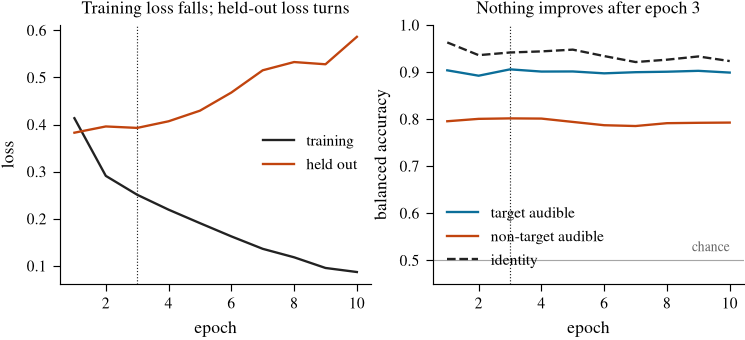

best epoch 3 of 10   train loss 0.414 -> 0.087   held-out 0.383 -> 0.586
A best epoch this early means the head memorises almost immediately:
the fix is more trials, not more epochs.


In [19]:
# --- 1. training: where the best epoch is, and how fast it overfits --------
epochs = [h["epoch"] for h in history]
figure, (loss_axis, score_axis) = plt.subplots(
    1, 2, figsize=(TEXTWIDTH_IN, 2.4))

loss_axis.plot(epochs, [h["training_loss"] for h in history],
               color=INK, lw=1.2, label="training")
loss_axis.plot(epochs, [h["holdout_loss"] for h in history],
               color=ACCENT2, lw=1.2, label="held out")
loss_axis.set_xlabel("epoch")
loss_axis.set_ylabel("loss")
loss_axis.set_title("Training loss falls; held-out loss turns")
loss_axis.legend(frameon=False)

best_epoch = max(history, key=lambda h: h["mean_balanced"])["epoch"]
for axis in (loss_axis, score_axis):
    axis.axvline(best_epoch, color=INK, lw=0.6, ls=":", zorder=0)

for name in QUESTIONS:
    score_axis.plot(epochs, [h["per_question"][name] for h in history],
                    color=QUESTION_COLOUR[name], lw=1.2, label=name)
score_axis.plot(epochs, [h["identity"] for h in history],
                color=INK, lw=1.2, ls="--", label="identity")
score_axis.axhline(CHANCE, color=INK, lw=0.6, ls="-", alpha=0.4)
score_axis.text(epochs[-1], CHANCE + 0.01, "chance", ha="right", va="bottom",
                fontsize=7, color=INK, alpha=0.7)
score_axis.set_xlabel("epoch")
score_axis.set_ylabel("balanced accuracy")
score_axis.set_ylim(0.45, 1.0)
score_axis.set_title(f"Nothing improves after epoch {best_epoch}")
score_axis.legend(frameon=False, loc="lower left")

save_figure(figure, "state_detector_training")
plt.show()

print(f"best epoch {best_epoch} of {len(history)}   "
      f"train loss {history[0]['training_loss']:.3f} -> "
      f"{history[-1]['training_loss']:.3f}   "
      f"held-out {history[0]['holdout_loss']:.3f} -> "
      f"{history[-1]['holdout_loss']:.3f}")
print("A best epoch this early means the head memorises almost immediately:")
print("the fix is more trials, not more epochs.")

saved report/figures/state_detector_operating_points.pdf


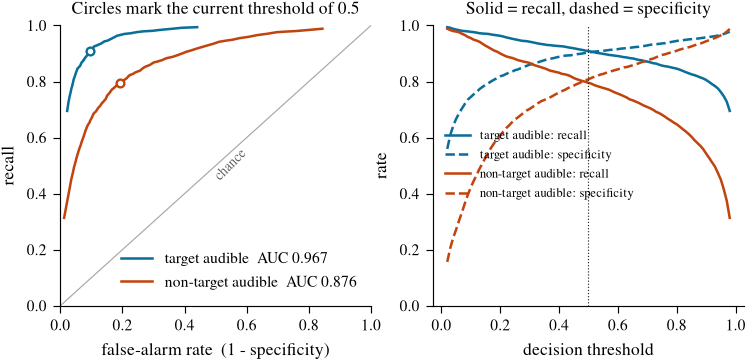

How to read the left panel: a curve hugging the top-left corner is a
good detector at SOME threshold. If a circle sits far from the curve's
shoulder, 0.5 is simply the wrong place to stand and the fix is free.

How to read the right panel, and this is the decision:
  target audible  -> a miss deletes target speech the judge never
     hears, so follow the SOLID line up: LOWER the threshold.
  non-target audible  -> a false alarm punishes output that was already
     clean, so follow the DASHED line up: RAISE the threshold.


In [20]:
# --- 2. operating points: the two curves, and where to stand ---------------
def curve(scores, is_positive, thresholds):
    """Recall and specificity at every threshold."""
    recall, specificity = [], []
    for threshold in thresholds:
        predicted = scores >= threshold
        recall.append((predicted & is_positive).sum()
                      / max(is_positive.sum(), 1))
        specificity.append((~predicted & ~is_positive).sum()
                           / max((~is_positive).sum(), 1))
    return np.array(recall), np.array(specificity)


thresholds = np.linspace(0.02, 0.98, 97)
figure, (roc_axis, sweep_axis) = plt.subplots(
    1, 2, figsize=(TEXTWIDTH_IN, 2.6))

roc_axis.plot([0, 1], [0, 1], color=INK, lw=0.6, alpha=0.4)
roc_axis.text(0.55, 0.5, "chance", fontsize=7, color=INK, alpha=0.7,
              rotation=45, ha="center", va="center")

for column, name in enumerate(QUESTIONS):
    scores, actual = probabilities[:, column], labels[:, column]
    recall, specificity = curve(scores, actual, thresholds)
    auc = area_under_curve(scores, actual)
    colour = QUESTION_COLOUR[name]

    roc_axis.plot(1 - specificity, recall, color=colour, lw=1.3,
                  label=f"{name}  AUC {auc:.3f}")
    # Where 0.5 actually puts you.
    at_half = np.argmin(np.abs(thresholds - 0.5))
    roc_axis.plot(1 - specificity[at_half], recall[at_half], "o",
                  color=colour, ms=4, mfc="white", mew=1.2)

    sweep_axis.plot(thresholds, recall, color=colour, lw=1.3, label=f"{name}: recall")
    sweep_axis.plot(thresholds, specificity, color=colour, lw=1.3, ls="--",
                    label=f"{name}: specificity")

roc_axis.set_xlabel("false-alarm rate  (1 - specificity)")
roc_axis.set_ylabel("recall")
roc_axis.set_title("Circles mark the current threshold of 0.5")
roc_axis.legend(frameon=False, loc="lower right")
roc_axis.set_xlim(0, 1)
roc_axis.set_ylim(0, 1)

sweep_axis.axvline(0.5, color=INK, lw=0.6, ls=":")
sweep_axis.set_xlabel("decision threshold")
sweep_axis.set_ylabel("rate")
sweep_axis.set_title("Solid = recall, dashed = specificity")
sweep_axis.legend(frameon=False, fontsize=6.5, loc="center left")
sweep_axis.set_ylim(0, 1)

save_figure(figure, "state_detector_operating_points")
plt.show()

print("How to read the left panel: a curve hugging the top-left corner is a")
print("good detector at SOME threshold. If a circle sits far from the curve's")
print("shoulder, 0.5 is simply the wrong place to stand and the fix is free.")
print()
print("How to read the right panel, and this is the decision:")
print(f"  {QUESTIONS[0]}  -> a miss deletes target speech the judge never")
print("     hears, so follow the SOLID line up: LOWER the threshold.")
print(f"  {QUESTIONS[1]}  -> a false alarm punishes output that was already")
print("     clean, so follow the DASHED line up: RAISE the threshold.")

saved report/figures/state_detector_confusion.pdf


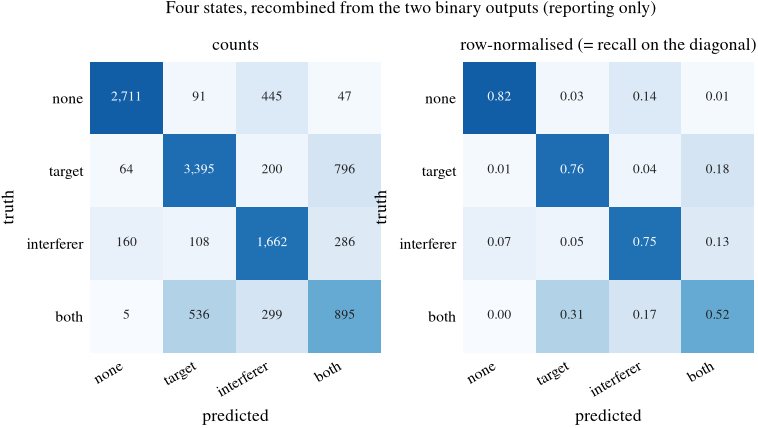

weakest state: both at 0.516 recall, most often called target (0.309)
`both` is the conjunction of the two questions, so it inherits BOTH
their error rates -- which is why it reads worse than either question.


In [21]:
# --- 3. confusion, as a picture -------------------------------------------
figure, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 2.7))

row_normalised = confusion / np.maximum(confusion.sum(axis=1, keepdims=True), 1)
for axis, matrix, title, fmt in (
        (axes[0], confusion, "counts", "{:,}"),
        (axes[1], row_normalised, "row-normalised (= recall on the diagonal)",
         "{:.2f}")):
    image = axis.imshow(row_normalised, cmap="Blues", vmin=0, vmax=1)
    axis.set_xticks(range(sl.N_STATES))
    axis.set_yticks(range(sl.N_STATES))
    axis.set_xticklabels(sl.STATE_NAMES, rotation=30, ha="right")
    axis.set_yticklabels(sl.STATE_NAMES)
    axis.set_xlabel("predicted")
    axis.set_ylabel("truth")
    axis.set_title(title)
    for row in range(sl.N_STATES):
        for column in range(sl.N_STATES):
            shade = row_normalised[row, column]
            axis.text(column, row, fmt.format(matrix[row, column]),
                      ha="center", va="center", fontsize=7,
                      color="white" if shade > 0.55 else INK)
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.tick_params(length=0)

figure.suptitle("Four states, recombined from the two binary outputs "
                "(reporting only)", fontsize=9, y=1.04)
save_figure(figure, "state_detector_confusion")
plt.show()

diagonal = np.diag(row_normalised)
worst = int(np.argmin(diagonal))
off_diagonal = row_normalised[worst].copy()
off_diagonal[worst] = 0
confused_with = int(np.argmax(off_diagonal))
print(f"weakest state: {sl.STATE_NAMES[worst]} at {diagonal[worst]:.3f} "
      f"recall, most often called {sl.STATE_NAMES[confused_with]} "
      f"({off_diagonal[confused_with]:.3f})")
print("`both` is the conjunction of the two questions, so it inherits BOTH")
print("their error rates -- which is why it reads worse than either question.")

saved report/figures/state_detector_cosine_by_state.pdf


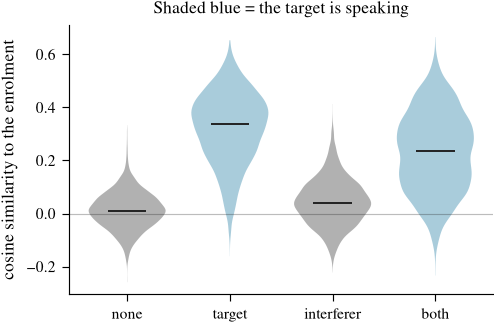

mean cosine: none +0.012   target +0.321   interferer +0.044   both +0.233

This one picture explains the whole result:
  `target` +0.321 vs `interferer` +0.044 -- far apart, so IDENTITY is easy
  `both` +0.233 sits between them and close to `target`,
  because ECAPA embeds whichever voice dominates. So a single scalar
  cannot tell 'target' from 'target plus someone else' -- plain cosine
  scores 0.405 on that question, BELOW chance.
  The head reaches ~0.76 using all 192 dimensions, which is exactly
  where it earns its keep.


In [22]:
# --- 4. why overlap is hard: the cosine distributions ----------------------
# Recomputed from the cache rather than the model: this is a property of the
# FEATURES, and it is the reason the non-target question is the harder one.
cosine_by_state = {state: [] for state in range(sl.N_STATES)}
for file_path in full_dataset.files[:300]:
    cached = np.load(file_path)
    enrolment_unit = cached["enrolment"].astype(np.float32)
    enrolment_unit /= np.linalg.norm(enrolment_unit)
    for variant in range(full_dataset.n_variants):
        windows = cached["embeddings"][variant].astype(np.float32)
        windows /= np.linalg.norm(windows, axis=1, keepdims=True)
        similarity = windows @ enrolment_unit
        window_labels, window_purity = full_dataset.labels_for(cached, variant)
        states = four_way_states(window_labels[:, 0].astype(bool),
                                 window_labels[:, 1].astype(bool))
        clean = window_purity.min(axis=1) >= 0.8
        for state in range(sl.N_STATES):
            keep = clean & (states == state)
            if keep.any():
                cosine_by_state[state].append(similarity[keep])

figure, axis = plt.subplots(figsize=(TEXTWIDTH_IN * 0.62, 2.5))
positions = range(sl.N_STATES)
data = [np.concatenate(cosine_by_state[state]) for state in positions]
parts = axis.violinplot(data, positions=list(positions), widths=0.75,
                        showextrema=False, showmedians=True)
for body, state in zip(parts["bodies"], positions):
    body.set_facecolor(ACCENT if state in (sl.TARGET, sl.BOTH) else INK)
    body.set_alpha(0.35)
    body.set_edgecolor("none")
parts["cmedians"].set_color(INK)
parts["cmedians"].set_linewidth(1.0)

axis.set_xticks(list(positions))
axis.set_xticklabels(sl.STATE_NAMES)
axis.set_ylabel("cosine similarity to the enrolment")
axis.set_title("Shaded blue = the target is speaking")
axis.axhline(0, color=INK, lw=0.6, alpha=0.3)

save_figure(figure, "state_detector_cosine_by_state")
plt.show()

means = {sl.STATE_NAMES[s]: float(np.mean(data[s])) for s in positions}
print("mean cosine: " + "   ".join(f"{k} {v:+.3f}" for k, v in means.items()))
print()
print("This one picture explains the whole result:")
print(f"  `target` {means['target']:+.3f} vs `interferer` "
      f"{means['interferer']:+.3f} -- far apart, so IDENTITY is easy")
print(f"  `both` {means['both']:+.3f} sits between them and close to `target`,")
print("  because ECAPA embeds whichever voice dominates. So a single scalar")
print("  cannot tell 'target' from 'target plus someone else' -- plain cosine")
print("  scores 0.405 on that question, BELOW chance.")
print("  The head reaches ~0.76 using all 192 dimensions, which is exactly")
print("  where it earns its keep.")

In [23]:
# --- what the threshold change actually bought ----------------------------
# Uses the probabilities already collected, so no forward pass and no
# retraining. Compares the default operating point against the chosen one.
COMPARE = {QUESTIONS[0]: [0.50, 0.50], QUESTIONS[1]: [0.50, 0.50]}

print(f"{'question':22s} {'thr':>5s} {'recall':>8s} {'spec':>8s} "
      f"{'balanced':>9s} {'precision':>10s}")
for column, name in enumerate(QUESTIONS):
    actual = labels[:, column]
    scores = probabilities[:, column]
    chosen = float(DECISION_THRESHOLD[column])
    for threshold in sorted(set(COMPARE[name] + [chosen])):
        predicted = scores >= threshold
        recall = (predicted & actual).sum() / max(actual.sum(), 1)
        specificity = (~predicted & ~actual).sum() / max((~actual).sum(), 1)
        precision = (predicted & actual).sum() / max(predicted.sum(), 1)
        marker = "  <- in use" if abs(threshold - chosen) < 1e-9 else ""
        print(f"  {name:20s} {threshold:>5.2f} {recall:>8.3f} "
              f"{specificity:>8.3f} {0.5 * (recall + specificity):>9.3f} "
              f"{precision:>10.3f}{marker}")
    print()

print("Read the change as a trade, not an improvement: balanced accuracy will")
print("barely move, because raising a threshold buys specificity and pays in")
print("recall. What the threshold decides is WHICH error the loss makes more")
print("often -- and for the non-target question, false-alarming on clean output")
print("is the more damaging of the two.")

question                 thr   recall     spec  balanced  precision
  target audible        0.50    0.908    0.903     0.906      0.914  <- in use

  non-target audible    0.50    0.795    0.808     0.802      0.679  <- in use

Read the change as a trade, not an improvement: balanced accuracy will
barely move, because raising a threshold buys specificity and pays in
recall. What the threshold decides is WHICH error the loss makes more
often -- and for the non-target question, false-alarming on clean output
is the more damaging of the two.


# 13. Hyperparameter search

Optuna (Akiba et al., KDD 2019). `optuna==5.0.0`, pinned in
`requirements.txt`.

**A THREE-way split, not two.** Choosing hyperparameters on the same set you
report on overfits that set — the search will find the configuration that
happens to suit those particular trials. So:

| split | share | used for |
|---|---|---|
| train | 70 % | fitting the head |
| **search** | 15 % | Optuna's objective — touched hundreds of times |
| **report** | 15 % | the final number — touched once |

The truly honest test is still a cache built from `sir0_val`, which is
speaker-disjoint by construction. These three come from `sir0_train`, so they
share speakers.

**The objective is the mean of the two AUCs**, not balanced accuracy.
Threshold-free, so the search cannot win by finding a lucky operating point —
the threshold is chosen separately, afterwards, from the sweep.

**`AUDIBLE_DB` is deliberately NOT searched.** It defines what counts as a
second voice being present, so it defines the *task*. A looser value makes the
problem easier and the score higher for a reason that is not progress. Searching
it would be optimising the question rather than the answer.

`MIN_TRAINING_PURITY` **is** searched, because it only decides which windows
enter the loss. Evaluation always uses every window, so it cannot make the task
easier.

**Pruning is on:** a trial reports its score each epoch, and Optuna kills
configurations already behind the median. Roughly halves the wall time.

In [24]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEARCH_FRACTION = 0.15
REPORT_FRACTION = 0.15

all_trial_ids = sorted({Path(f).stem.split("__")[1]
                        for f in glob.glob(str(CACHE / f"{CACHE_SPLIT}__*.npz"))})
splitter = np.random.default_rng(RANDOM_SEED)
splitter.shuffle(all_trial_ids)

n_search = int(round(SEARCH_FRACTION * len(all_trial_ids)))
n_report = int(round(REPORT_FRACTION * len(all_trial_ids)))
report_ids = all_trial_ids[:n_report]
search_ids = all_trial_ids[n_report:n_report + n_search]
fit_ids = all_trial_ids[n_report + n_search:]

print(f"{len(all_trial_ids)} trials cached")
print(f"  fit    {len(fit_ids):5d}")
print(f"  search {len(search_ids):5d}   (Optuna's objective)")
print(f"  report {len(report_ids):5d}   (touched once, at the end)")

fit_dataset = StateCache(CACHE, CACHE_SPLIT, trial_ids=fit_ids)
search_dataset = StateCache(CACHE, CACHE_SPLIT, trial_ids=search_ids)
report_dataset = StateCache(CACHE, CACHE_SPLIT, trial_ids=report_ids)

# pos_weight from the FIT split only. Deriving it from everything would leak
# the search and report splits' class balance into training.
fit_positives, fit_totals = np.zeros(2, dtype=np.int64), np.zeros(2, dtype=np.int64)
for file_path in fit_dataset.files:
    cached = np.load(file_path)
    for variant in range(fit_dataset.n_variants):
        window_labels, _ = fit_dataset.labels_for(cached, variant)
        fit_positives += window_labels.astype(bool).sum(axis=0)
        fit_totals += len(window_labels)
fit_positive_weight = torch.tensor(
    (fit_totals - fit_positives) / np.maximum(fit_positives, 1),
    dtype=torch.float32)
print(f"pos_weight from the fit split: "
      f"{[round(float(w), 2) for w in fit_positive_weight]}")

/home/grant/Documents/University/Masters/Project/tse_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1000 trials cached
  fit      700
  search   150   (Optuna's objective)
  report   150   (touched once, at the end)
pos_weight from the fit split: [0.82, 1.95]


In [25]:
class SearchableHead(nn.Module):
    """StateHead with a configurable recurrent trunk, so the search can vary it.

    Identical to StateHead at hidden=128, n_layers=1, dropout=0.1. The
    per-window features are byte-identical to it -- same two LayerNorms, same
    elementwise product, same explicit cosine -- so the only things the search
    varies are the trunk and the optimiser.

    THIS WAS THE PER-WINDOW MLP UNTIL 2026-09-11, and a 42-trial search against
    that version reached mean AUC 0.8907 from a baseline of 0.8836. The BiLSTM
    scores 0.9216 with no search at all, so those 42 trials were spent tuning an
    architecture that had already been replaced -- 0.7 points of search against
    3.8 points of architecture. Recorded so the wasted run is not repeated.
    """

    def __init__(self, hidden, n_layers, dropout, embedding_dim=EMBEDDING_DIM,
                 n_outputs=2):
        super().__init__()
        self.norm_window = nn.LayerNorm(embedding_dim)
        self.norm_enrolment = nn.LayerNorm(embedding_dim)
        self.project = nn.Sequential(
            nn.Linear(3 * embedding_dim + 1, hidden), nn.GELU())
        self.across_windows = nn.LSTM(
            hidden, hidden, num_layers=n_layers, batch_first=True,
            bidirectional=True,
            # PyTorch ignores dropout on a single-layer LSTM and warns; pass 0
            # so the warning does not bury 40 trials of output.
            dropout=dropout if n_layers > 1 else 0.0)
        self.output = nn.Sequential(nn.Dropout(dropout),
                                    nn.Linear(2 * hidden, n_outputs))

    def forward(self, window_embeddings, enrolment_embedding):
        window_unit = torch.nn.functional.normalize(window_embeddings, dim=-1)
        enrolment_unit = torch.nn.functional.normalize(enrolment_embedding,
                                                       dim=-1)
        cosine = (window_unit * enrolment_unit.unsqueeze(1)).sum(-1,
                                                                 keepdim=True)
        window = self.norm_window(window_embeddings)
        enrolment = self.norm_enrolment(enrolment_embedding)
        enrolment = enrolment.unsqueeze(1).expand_as(window)
        hidden = self.project(
            torch.cat([window, enrolment, window * enrolment, cosine], dim=-1))
        hidden, _ = self.across_windows(hidden)
        return self.output(hidden)


@torch.no_grad()
def evaluate_auc(head, loader):
    """Mean of the two questions' AUC, plus each separately.

    Threshold-free on purpose: the search must not be able to win by landing on
    a lucky operating point. The thresholds are chosen afterwards, from the
    sweep, and the loss itself never thresholds at all.
    """
    head.eval()
    probability_rows, label_rows = [], []
    for embeddings, enrolment, window_labels, _ in loader:
        logits = head(embeddings.to(DEVICE), enrolment.to(DEVICE))
        probability_rows.append(torch.sigmoid(logits).reshape(-1, 2).cpu())
        label_rows.append(window_labels.reshape(-1, 2))
    scores = torch.cat(probability_rows).numpy()
    truth = torch.cat(label_rows).numpy().astype(bool)
    per_question = [area_under_curve(scores[:, c], truth[:, c])
                    for c in range(2)]
    return float(np.mean(per_question)), per_question


def train_one_configuration(parameters, fit_ids, evaluate_ids,
                            trial=None, max_epochs=25, verbose=False):
    """Fit a head under one setting. Returns (best mean AUC, weights, epoch).

    `trial` enables Optuna's pruner: the score is reported each epoch and a
    configuration already behind the median is abandoned. On the 2026-09-11 run
    that killed 28 of 42 trials and cut the search from 3 min a trial to 25 s.
    """
    torch.manual_seed(RANDOM_SEED)

    fit = StateCache(CACHE, CACHE_SPLIT, trial_ids=fit_ids,
                     rotate_enrolment=ROTATE_ENROLMENT)
    evaluate = StateCache(CACHE, CACHE_SPLIT, trial_ids=evaluate_ids)
    fit_loader = DataLoader(fit, batch_size=parameters["batch_size"],
                            shuffle=True, num_workers=4, drop_last=True)
    evaluate_loader = DataLoader(evaluate, batch_size=64, shuffle=False,
                                 num_workers=4)

    head = SearchableHead(parameters["hidden"], parameters["n_layers"],
                          parameters["dropout"]).to(DEVICE)
    loss_function = nn.BCEWithLogitsLoss(
        pos_weight=fit_positive_weight.to(DEVICE), reduction="none")
    optimiser = torch.optim.AdamW(head.parameters(),
                                  lr=parameters["learning_rate"],
                                  weight_decay=parameters["weight_decay"])

    best_auc, best_state, best_epoch = -1.0, None, 0
    for epoch in range(1, max_epochs + 1):
        # Without this the enrolment rotation is a silent no-op and every epoch
        # draws the same variant.
        fit.set_epoch(epoch)
        head.train()
        for embeddings, enrolment, window_labels, purity in fit_loader:
            embeddings, enrolment = embeddings.to(DEVICE), enrolment.to(DEVICE)
            window_labels, purity = window_labels.to(DEVICE), purity.to(DEVICE)
            elementwise = loss_function(head(embeddings, enrolment),
                                        window_labels)
            scorable = purity >= parameters["min_purity"]
            if not scorable.any():
                continue
            loss = (elementwise * scorable).sum() / scorable.sum()
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

        mean_auc, per_question = evaluate_auc(head, evaluate_loader)
        if mean_auc > best_auc:
            best_auc, best_epoch = mean_auc, epoch
            best_state = {k: v.detach().clone()
                          for k, v in head.state_dict().items()}
        if verbose:
            print(f"    epoch {epoch:2d}  mean AUC {mean_auc:.4f}  "
                  f"target {per_question[0]:.4f}  "
                  f"non-target {per_question[1]:.4f}")
        if trial is not None:
            trial.report(mean_auc, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    return best_auc, best_state, best_epoch


# The bar to beat: the BiLSTM at its hand-picked settings. MEASURED on the
# search split -- mean AUC 0.9216, target 0.9721, non-target 0.8710.
print("baseline: the BiLSTM at hand-picked settings, for something to beat")
baseline_parameters = dict(hidden=128, n_layers=1, dropout=0.1,
                           learning_rate=3e-4, weight_decay=1e-4,
                           batch_size=16, min_purity=0.8)
baseline_auc, _, baseline_epoch = train_one_configuration(
    baseline_parameters, fit_ids, search_ids, max_epochs=12, verbose=True)
print(f"baseline mean AUC {baseline_auc:.4f} at epoch {baseline_epoch}")
print("for reference, the per-window MLP this replaced: 0.8836, and a 42-trial")
print("search over IT reached only 0.8907")

baseline: the BiLSTM at hand-picked settings, for something to beat
    epoch  1  mean AUC 0.9224  target 0.9740  non-target 0.8708
    epoch  2  mean AUC 0.9252  target 0.9764  non-target 0.8740
    epoch  3  mean AUC 0.9219  target 0.9791  non-target 0.8646
    epoch  4  mean AUC 0.9206  target 0.9786  non-target 0.8625
    epoch  5  mean AUC 0.9178  target 0.9778  non-target 0.8579
    epoch  6  mean AUC 0.9161  target 0.9786  non-target 0.8536
    epoch  7  mean AUC 0.9152  target 0.9765  non-target 0.8539
    epoch  8  mean AUC 0.9118  target 0.9769  non-target 0.8467
    epoch  9  mean AUC 0.9189  target 0.9766  non-target 0.8611
    epoch 10  mean AUC 0.9188  target 0.9771  non-target 0.8605
    epoch 11  mean AUC 0.9167  target 0.9758  non-target 0.8575
    epoch 12  mean AUC 0.9156  target 0.9766  non-target 0.8547
baseline mean AUC 0.9252 at epoch 2
for reference, the per-window MLP this replaced: 0.8836, and a 42-trial
search over IT reached only 0.8907


In [ ]:
N_OPTUNA_TRIALS = 60
MAX_EPOCHS_PER_TRIAL = 25


def objective(trial):
    parameters = dict(
        hidden=trial.suggest_int("hidden", 32, 256, log=True),
        n_layers=trial.suggest_int("n_layers", 1, 2),
        dropout=trial.suggest_float("dropout", 0.0, 0.5),
        learning_rate=trial.suggest_float("learning_rate", 1e-4, 3e-3,
                                          log=True),
        weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True),
        batch_size=trial.suggest_categorical("batch_size", [8, 16, 32, 64]),
        min_purity=trial.suggest_float("min_purity", 0.5, 0.95),
    )
    best_auc, _, best_epoch = train_one_configuration(
        parameters, fit_ids, search_ids, trial=trial,
        max_epochs=MAX_EPOCHS_PER_TRIAL)
    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("n_parameters", sum(
        p.numel() for p in SearchableHead(parameters["hidden"],
                                          parameters["n_layers"],
                                          parameters["dropout"]).parameters()))
    return best_auc

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_SEED, n_startup_trials=10),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=4),
    study_name="state_detector_bilstm")

import time
started_at = time.time()
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False,
               callbacks=[lambda s, t: print(
                   f"trial {t.number:3d}  {str(t.state.name):9s} "
                   f"{'' if t.value is None else f'{t.value:.4f}'}"
                   f"   best {s.best_value:.4f}"
                   f"   [{(time.time() - started_at) / 60:.0f} min]")])

completed = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\n{len(study.trials)} trials in {(time.time() - started_at) / 60:.0f} min"
      f"  ({len(completed)} completed, {len(pruned)} pruned)")
print(f"best mean AUC {study.best_value:.4f} against the BiLSTM baseline's "
      f"{baseline_auc:.4f} ({study.best_value - baseline_auc:+.4f})")
print()
print("How to read that difference. The previous search moved 0.8836 -> 0.8907")
print("(+0.007) over 42 trials, while swapping the head moved 0.8836 -> 0.9216")
print("(+0.038) for free. So anything under about +0.01 here is the search")
print("confirming the hyperparameters do not matter much -- which is a")
print("legitimate finding and belongs in the write-up as one.")

trial   0  COMPLETE  0.9246   best 0.9246   [3 min]
trial   1  COMPLETE  0.9229   best 0.9246   [5 min]
trial   2  COMPLETE  0.9292   best 0.9292   [9 min]
trial   3  COMPLETE  0.9278   best 0.9292   [13 min]
trial   4  COMPLETE  0.9275   best 0.9292   [17 min]
trial   5  COMPLETE  0.9256   best 0.9292   [31 min]
trial   6  COMPLETE  0.9254   best 0.9292   [34 min]
trial   7  COMPLETE  0.9256   best 0.9292   [37 min]
trial   8  COMPLETE  0.9250   best 0.9292   [41 min]
trial   9  PRUNED    0.9181   best 0.9292   [42 min]
trial  10  COMPLETE  0.9245   best 0.9292   [45 min]
trial  11  COMPLETE  0.9281   best 0.9292   [48 min]
trial  12  COMPLETE  0.9280   best 0.9292   [51 min]
trial  13  COMPLETE  0.9262   best 0.9292   [54 min]
trial  14  COMPLETE  0.9275   best 0.9292   [57 min]
trial  15  COMPLETE  0.9243   best 0.9292   [60 min]
trial  16  COMPLETE  0.9261   best 0.9292   [65 min]
trial  17  COMPLETE  0.9269   best 0.9292   [71 min]
trial  18  COMPLETE  0.9248   best 0.9292   [75 m

In [ ]:
# --- what the search found, and whether it is worth believing --------------
best = study.best_trial
print(f"best trial {best.number}, mean AUC {best.value:.4f}, "
      f"epoch {best.user_attrs['best_epoch']}, "
      f"{best.user_attrs['n_parameters'] / 1e3:.0f} k parameters")
print()
for name, value in sorted(best.params.items()):
    baseline_value = dict(n_layers=1, hidden_0=256, dropout=0.1,
                          learning_rate=3e-4, weight_decay=1e-4,
                          batch_size=16, min_purity=0.8).get(name)
    shown = f"{value:.5g}" if isinstance(value, float) else str(value)
    against = "" if baseline_value is None else f"   (was {baseline_value})"
    print(f"  {name:16s} {shown:>10s}{against}")

# Which knobs mattered. fANOVA over the completed trials: if a parameter's
# importance is near zero, the search is telling you it does not matter and the
# write-up should say so rather than quoting the tuned value as meaningful.
try:
    importances = optuna.importance.get_param_importances(study)
    print("\nparameter importance (fANOVA, sums to 1):")
    for name, weight in importances.items():
        bar = "#" * int(round(40 * weight))
        print(f"  {name:16s} {weight:5.3f}  {bar}")
except Exception as error:
    print(f"\nimportance unavailable: {error}")

In [ ]:
# --- refit the winner, then read the REPORT split ONCE ---------------------
best_parameters = dict(
    hidden=best.params["hidden"],
    n_layers=best.params["n_layers"],
    dropout=best.params["dropout"],
    learning_rate=best.params["learning_rate"],
    weight_decay=best.params["weight_decay"],
    batch_size=best.params["batch_size"],
    min_purity=best.params["min_purity"],
)

_, best_state, best_epoch = train_one_configuration(
    best_parameters, fit_ids, search_ids,
    max_epochs=MAX_EPOCHS_PER_TRIAL, verbose=False)

tuned_head = SearchableHead(best_parameters["hidden"],
                            best_parameters["n_layers"],
                            best_parameters["dropout"]).to(DEVICE)
tuned_head.load_state_dict(best_state)

report_loader = DataLoader(report_dataset, batch_size=64, shuffle=False,
                           num_workers=4)
search_loader = DataLoader(search_dataset, batch_size=64, shuffle=False,
                           num_workers=4)

search_mean, search_per = evaluate_auc(tuned_head, search_loader)
report_mean, report_per = evaluate_auc(tuned_head, report_loader)

print(f"{'split':10s} {'mean AUC':>9s} {'target':>9s} {'non-target':>12s}")
print(f"{'search':10s} {search_mean:>9.4f} {search_per[0]:>9.4f} "
      f"{search_per[1]:>12.4f}   (chosen on this)")
print(f"{'report':10s} {report_mean:>9.4f} {report_per[0]:>9.4f} "
      f"{report_per[1]:>12.4f}   (touched once)")
print()
print(f"search-to-report drop: {search_mean - report_mean:+.4f}")
print("A large drop means the search fitted the search split rather than the")
print("problem. Quote the REPORT number; the search number is not a result.")
print()
print("Mean AUC on the search split, for orientation:")
print("  per-window MLP, hand-picked        0.8836")
print("  per-window MLP, 42-trial search    0.8907")
print("  BiLSTM, hand-picked                0.9216   target 0.9721  non-target 0.8710")
print(f"  BiLSTM, this search                {study.best_value:.4f}")

detector_head = tuned_head
DECISION_THRESHOLD = torch.tensor([0.50, 0.5])

In [ ]:
# --- log it, per CLAUDE.md: config, commit, metrics, date, seed ------------
import subprocess
from datetime import date

def git_commit():
    try:
        head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True,
                              text=True, check=True, timeout=10).stdout.strip()
        dirty = subprocess.run(["git", "status", "--porcelain"],
                               capture_output=True, text=True, check=True,
                               timeout=10).stdout.strip()
        return head + ("-dirty" if dirty else "")
    except Exception:
        return "UNKNOWN"

results_dir = REPO / "experiments" / "results" / \
    f"{date.today().isoformat()}-state-detector-optuna"
results_dir.mkdir(parents=True, exist_ok=True)

record = dict(
    date=date.today().isoformat(),
    git_commit=git_commit(),
    seed=RANDOM_SEED,
    backbone="ECAPA-TDNN speechbrain/spkrec-ecapa-voxceleb",
    ecapa_hashes=ECAPA_HASHES,
    questions=list(QUESTIONS),
    # Fixed, NOT searched: these define the task rather than the model.
    audible_db=AUDIBLE_DB,
    window_seconds=WINDOW_SECONDS,
    window_hop_seconds=WINDOW_HOP_SECONDS,
    chunk_seconds=CHUNK_SECONDS,
    n_variants=NUMBER_OF_VARIANTS,
    splits=dict(fit=len(fit_ids), search=len(search_ids),
                report=len(report_ids)),
    n_optuna_trials=len(study.trials),
    n_completed=len([t for t in study.trials if t.state.name == "COMPLETE"]),
    n_pruned=len([t for t in study.trials if t.state.name == "PRUNED"]),
    baseline_search_auc=baseline_auc,
    best_params=best.params,
    best_epoch=best_epoch,
    n_head_parameters=int(sum(p.numel() for p in tuned_head.parameters())),
    search_auc=dict(mean=search_mean, target=search_per[0],
                    non_target=search_per[1]),
    report_auc=dict(mean=report_mean, target=report_per[0],
                    non_target=report_per[1]),
    decision_threshold=DECISION_THRESHOLD.tolist(),
    trials=[dict(number=t.number, state=t.state.name, value=t.value,
                 params=t.params, best_epoch=t.user_attrs.get("best_epoch"))
            for t in study.trials],
)
(results_dir / "results.json").write_text(json.dumps(record, indent=2))

torch.save(dict(state_dict=tuned_head.state_dict(),
                head_class="SearchableHead",
                **{k: v for k, v in record.items() if k != "trials"}),
           REPO / "models" / "state_detector_tuned.pt")

print(f"wrote {(results_dir / 'results.json').relative_to(REPO)}")
print(f"wrote models/state_detector_tuned.pt")
print()
print("Still to do, and neither is optional before this teacher is used:")
print("  1. Cache sir0_val and re-measure there. It is speaker-disjoint by")
print("     construction; all three splits above share speakers.")
print("  2. Add a row to docs/run_times.md for the search.")

NameError: name 'REPO' is not defined